# DC Heat Wave July 2026 - Forecast Attribution at KDCA

**Author:** Sebastian Otarola-Bustos, PhD  
**Data:** ERA5 (Copernicus/ECMWF), ASOS/IEM, NBM and GFS via NOAA NODD, NASA GISTEMP (GMST)  
**Methodology:** Philip et al. (2020) — independent analysis, not peer-reviewed

On June 25, 2026, the GFS operational forecast showed 2-m temperatures approaching **38°C (100°F)** at Reagan National Airport (KDCA) around July 2–3. The latest NBM run (June 29 18Z) now shows a peak of **39.4°C (103°F)** on Friday July 3. If the forecast were to verify, it would be one of the hottest days on record at KDCA.

This notebook asks two questions:

1. **How rare is a 103°F (39.4°C) day at KDCA** in today's climate, based on 85 years of observations?
2. **How much did anthropogenic warming change the odds** of this event compared to a pre-industrial baseline?

The analysis uses only station observations and reanalysis. That limits precision (confidence intervals are wide from a single station), but keeps the methodology transparent and reproducible from public data sources.

---
*Data: NOAA ASOS hourly (KDCA, 1973–2025) · ERA5 via Open-Meteo (1940–2025) · NOAA NBM (init: 2026-06-29 18Z) · NASA GISTEMP v4*  
*Method: Philip et al. (2020), Adv. in Statistical Climatology, Meteorology and Oceanography, 6, 177–203*  
*Attribution framework: Stott et al. (2004), Nature, 432, 610–614*

In [1]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import requests, io
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import genextreme, linregress
from scipy.optimize import minimize

# Paths — notebook lives at analyses/dc_heatwave_2026/, data at repo root /data/
REPO_ROOT = Path('../..').resolve()
DATA_DIR  = REPO_ROOT / 'data'
ASOS_DIR  = DATA_DIR / 'asos_cache'
NBM_PATH  = DATA_DIR / 'dc_heatwave_nbm_20260630_1200Z_forecast.nc'
GFS_PATH  = DATA_DIR / 'dc_heatwave_gfs_20260630_0600Z_forecast.nc'
FIG_DIR   = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

KDCA_LAT, KDCA_LON = 38.9072, -77.0369

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.figsize':    (12.0, 5.0),
    'font.family':       'sans-serif',
    'font.size':         13,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'lines.linewidth':   2.0,
    'legend.frameon':    False,
})

## 1. Data

**Observations:** NOAA ASOS hourly surface data at KDCA (Reagan National Airport), fetched from the Iowa State Mesonet archive. ASOS covers the period from 1973 to 2025.

**Forecast:** NOAA NBM (National Blend of Models) initialized 2026-06-29 18Z, fetched via [Herbie](https://herbie.readthedocs.io/). T2m and dewpoint extracted at KDCA via Herbie and cached locally as NetCDF. NBM blends GFS, HRRR, and other operational models and is generally better calibrated for surface temperature than any single model.

> **Data download:** The required files (`asos_cache/KDCA_*.csv` and `dc_heatwave_nbm_20260629_1800Z_forecast.nc`) are available on [Google Drive](https://drive.google.com/drive/folders/1C3wo7wCyTcJ_UIX5HtNjwcqv6dB6Fwd-?usp=drive_link). Place them under `data/` at the repo root so the paths in the setup cell resolve correctly.

In [2]:
# ASOS hourly observations — concatenate cached CSVs
frames = []
for f in sorted(ASOS_DIR.glob('KDCA_*.csv')):
    df = pd.read_csv(f, parse_dates=['valid_utc'])
    frames.append(df)

kdca_all = pd.concat(frames, ignore_index=True)
kdca_all['valid_utc'] = pd.to_datetime(kdca_all['valid_utc'], utc=True)
kdca_all = kdca_all.sort_values('valid_utc').reset_index(drop=True)

# NBM forecast — init 2026-06-30 12Z
ds_nbm = xr.open_dataset(NBM_PATH)

# GFS forecast — init 2026-06-30 06Z
ds_gfs = xr.open_dataset(GFS_PATH)

print(f'KDCA: {len(kdca_all):,} hourly obs  ({kdca_all.valid_utc.dt.year.min()}–{kdca_all.valid_utc.dt.year.max()})')
print(f'NBM:  {NBM_PATH.name}')
print(f'      time range: {str(ds_nbm.time.values[0])[:16]} → {str(ds_nbm.time.values[-1])[:16]}')

KDCA: 458,807 hourly obs  (1973–2025)
NBM:  dc_heatwave_nbm_20260630_1200Z_forecast.nc
      time range: 2026-06-30T18:00 → 2026-07-07T12:00


## 2. The Historical Record: Annual JJA Block Maxima

To build a baseline for rarity, I extract one value per year: the highest daily maximum temperature during June, July, or August. This is the **annual JJA block maximum**.

Restricting to JJA keeps the sample physically homogeneous, i.e. the same synoptic regime, similar boundary layer conditions, consistent land surface forcing. Using annual block maxima (rather than all exceedances above some threshold) guarantees year-to-year independence.

In [3]:
jja_mask = kdca_all['valid_utc'].dt.month.isin([6, 7, 8])
ann_max  = kdca_all.loc[jja_mask].groupby(
    kdca_all.loc[jja_mask, 'valid_utc'].dt.year
)['temp_c'].max()

print(f'n = {len(ann_max)} years  ({ann_max.index[0]}–{ann_max.index[-1]})')
print(f'Range: {ann_max.min():.1f}–{ann_max.max():.1f}°C')
print(f'\nTop 10 hottest JJA years at KDCA:')
print(ann_max.sort_values(ascending=False).head(10).to_string())

n = 53 years  (1973–2025)
Range: 33.0–40.6°C

Top 10 hottest JJA years at KDCA:
valid_utc
2012    40.555556
1980    39.444444
2024    39.444444
1988    39.444444
2011    39.444444
1997    39.000000
1999    38.888889
2010    38.888889
1983    38.333333
1991    38.333333


## 3. Fitting a Stationary GEV

The GEV is the standard model for annual block maxima. It arises when you take the maximum of many observations (regardless of their underlying distribution), which is exactly what annual JJA maxima are. That's the key property that makes it appropriate here without needing to know the daily temperature distribution.

Its three parameters each describe something physically interpretable:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Location | $\mu$ | Center of the distribution and roughly the typical annual maximum |
| Scale | $\sigma$ | Year-to-year spread |
| Shape | $\xi$ | Tail: $\xi < 0$ → finite upper bound (Weibull), $\xi = 0$ → exponential decay (Gumbel), $\xi > 0$ → heavy tail (Fréchet) |

Parameters are estimated by maximum likelihood, fitting $\mu$, $\sigma$, and $\xi$ jointly. The negative shape ($\xi$ < 0) is physically expected, i.e. summer DC maxima can't grow without limit.

The **$T$-year return level** is the temperature exceeded with probability $1/T$ in any given year:

$$x_T = \mu - \frac{\sigma}{\xi}\left[1 - \left(-\ln\!\left(1 - \frac{1}{T}\right)\right)^{-\xi}\right]$$

Bootstrap CIs (500 resamples) propagate parameter uncertainty into the return level curves.

In [4]:
c, loc, scale = genextreme.fit(ann_max, method='MLE')

print('Stationary GEV parameters:')
print(f'  μ (location) = {loc:.2f}°C')
print(f'  σ (scale)    = {scale:.2f}°C')
print(f'  ξ (shape)    = {-c:.3f}  → Weibull tail, finite upper bound')

return_10 = genextreme.ppf(1 - 1/10,  c, loc, scale)
return_50 = genextreme.ppf(1 - 1/50,  c, loc, scale)

np.random.seed(42)
boot_10, boot_50 = [], []
for _ in range(500):
    sample       = np.random.choice(ann_max, size=len(ann_max), replace=True)
    c_b, l_b, s_b = genextreme.fit(sample, method='MLE')
    boot_10.append(genextreme.ppf(1 - 1/10, c_b, l_b, s_b))
    boot_50.append(genextreme.ppf(1 - 1/50, c_b, l_b, s_b))

ci_10 = (np.percentile(boot_10, 2.5), np.percentile(boot_10, 97.5))
ci_50 = (np.percentile(boot_50, 2.5), np.percentile(boot_50, 97.5))

print(f'\nReturn levels:')
print(f'  10-yr: {return_10:.1f}°C  [{ci_10[0]:.1f}, {ci_10[1]:.1f}]')
print(f'  50-yr: {return_50:.1f}°C  [{ci_50[0]:.1f}, {ci_50[1]:.1f}]')
print(f'All-time ASOS record: {ann_max.max():.1f}°C ({ann_max.max()*9/5+32:.1f}°F) in {ann_max.idxmax()}')

Stationary GEV parameters:
  μ (location) = 36.20°C
  σ (scale)    = 1.58°C
  ξ (shape)    = -0.266  → Weibull tail, finite upper bound



Return levels:
  10-yr: 38.9°C  [38.2, 39.3]
  50-yr: 40.0°C  [39.2, 40.8]
All-time ASOS record: 40.6°C (105.0°F) in 2012


**Parameters make physical sense.** $\mu$ = 36.2°C is the typical annual maximum and is indicative of the center of the distribution. $\sigma$ = 1.58°C reflects year-to-year swings from circulation and antecedent soil moisture. The Weibull shape ($\xi$ = −0.27) means the maxima is bounded.

**CI width reflects how much data we have.** The 10-yr CI [38.2, 39.3] is tight because we've actually observed events in that range several times. The 50-yr CI [39.2, 40.8] opens up because we've barely sampled that part of the tail.

## 4. The Forecast in Context

The analysis uses the **NBM (National Blend of Models)** initialized June 30 12Z as the reference forecast, with GFS June 30 06Z shown for comparison.

Both models agree on the event: **peak on Friday July 3 around 2 PM EDT**. GFS reaches **104°F** while NBM comes in at **102°F**, putting the likely event level around **103°F**. For reference, the all-time KDCA record of 105°F was set in 2012.

| Day | GFS 06Z (2 PM EDT) | NBM 12Z (2 PM EDT) |
|-----|---------------------|---------------------|
| Wed Jul 1 | 36.2°C (97°F) | 35.0°C (95°F) |
| Thu Jul 2 | 39.5°C (103°F) | 37.6°C (100°F) |
| **Fri Jul 3** | **40.2°C (104°F)** | **39.1°C (102°F)** |
| Sat Jul 4 | 40.0°C (104°F) | 37.6°C (100°F) |

The main model spread is on Saturday — NBM breaks faster than GFS. On the **103°F forecast level**, the stationary GEV gives roughly a **~20-year event** in today's climate (accounting for the warming trend shifts this to ~7 years). For the attribution analysis I use the **100°F threshold** — the forecast clearly exceeds it, and it gives more statistical power than conditioning on the exact peak.

In [5]:
# NBM 2-m temperature at KDCA (point extract - no spatial selection needed)
kdca_ts = ds_nbm['t2m'] - 273.15
kdca_tf = kdca_ts * 9/5 + 32

nbm_peak_c    = float(kdca_ts.max().values)
nbm_peak_f    = float(kdca_tf.max().values)
nbm_peak_time = kdca_ts.idxmax('time').values

# Attribution threshold: 100°F (37.778°C) — public-health benchmark with enough historical
# exceedances for reliable PR/FAR estimation. The forecast clearly exceeds it.
attr_threshold_c = 100 * 5/9 - 160/9  # exactly 100°F in °C (37.778°C)
attr_threshold_f = attr_threshold_c * 9/5 + 32

# GFS peak for Figure 2 reference (Jun 30 06Z, point extract at KDCA, Jul 3 18Z)
gfs_peak_c = 40.22
gfs_peak_f = gfs_peak_c * 9/5 + 32

# Stationary return period — attribution threshold (38°C) and actual forecast peak
nbm_rp       = 1 / genextreme.sf(attr_threshold_c, c, loc, scale)
nbm_peak_rp  = 1 / genextreme.sf(nbm_peak_c,       c, loc, scale)
event_103f_c = (103 - 32) * 5/9  # 39.444°C — between NBM (102°F) and GFS (104°F)
rp_103f_stat = 1 / genextreme.sf(event_103f_c,     c, loc, scale)

# Historical percentile envelope for the forecast window (±7 day DOY pooling)
kdca_all['valid_local'] = kdca_all['valid_utc'].dt.tz_convert('America/New_York')
kdca_all_daily = kdca_all.set_index('valid_local').resample('1D')['temp_c'].max()
kdca_ts_daily  = kdca_ts.resample(time='1D').max()

p10, p50, p90, dates = [], [], [], []
for day in pd.to_datetime(kdca_ts_daily.time.values):
    doy      = day.day_of_year
    doy_hist = kdca_all_daily.index.day_of_year
    diff     = np.minimum(np.abs(doy_hist - doy), 365 - np.abs(doy_hist - doy))
    pool     = kdca_all_daily[diff <= 7]
    if len(pool) < 20:
        continue
    dates.append(day)
    p10.append(pool.quantile(0.1))
    p50.append(pool.quantile(0.5))
    p90.append(pool.quantile(0.9))

env = pd.DataFrame({'date': dates, 'p10': p10, 'p50': p50, 'p90': p90})

print(f'NBM forecast peak: {nbm_peak_c:.1f}°C ({nbm_peak_f:.1f}°F)  on {pd.Timestamp(nbm_peak_time).strftime("%b %d %H UTC")}')
print(f'Attribution threshold: {attr_threshold_f:.0f}°F ({attr_threshold_c:.2f}°C)  — stationary return period: ~{nbm_rp:.0f} years')
print(f'Forecast level 103°F (39.4°C)  — stationary return period: ~{rp_103f_stat:.0f} years')

NBM forecast peak: 39.1°C (102.5°F)  on Jul 03 18 UTC
Attribution threshold: 100°F (37.78°C)  — stationary return period: ~4 years
Forecast level 103°F (39.4°C)  — stationary return period: ~20 years


In [6]:
# Wet-bulb temperature - heat stress context
# Stull (2011) empirical formula, accurate to ±0.35°C for 5°C < T < 50°C, 5% < RH < 99%

kdca_d2m = ds_nbm['d2m'] - 273.15

def magnus_rh(t_c, td_c):
    return 100 * np.exp(17.625 * td_c / (243.04 + td_c)) / np.exp(17.625 * t_c / (243.04 + t_c))

def stull_wetbulb(t_c, rh):
    return (t_c * np.arctan(0.151977 * (rh + 8.313659)**0.5)
            + np.arctan(t_c + rh)
            - np.arctan(rh - 1.676331)
            + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh)
            - 4.686035)

rh_fc   = magnus_rh(kdca_ts.values, kdca_d2m.values)
tw_vals = stull_wetbulb(kdca_ts.values, rh_fc)
kdca_tw = xr.DataArray(tw_vals, coords={'time': kdca_ts.time}, dims=['time'])

peak_tw      = float(kdca_tw.max().values)
peak_tw_time = kdca_ts.time[int(kdca_tw.argmax())].values

print(f'Peak dry-bulb:  {nbm_peak_c:.1f}°C ({nbm_peak_f:.1f}°F)  {pd.Timestamp(nbm_peak_time).strftime("%b %d %H UTC")}')
print(f'Peak wet-bulb:  {peak_tw:.1f}°C ({peak_tw*9/5+32:.1f}°F)  {pd.Timestamp(peak_tw_time).strftime("%b %d %H UTC")}')

if peak_tw >= 35:
    risk = 'CRITICAL — above theoretical survival limit for resting humans in shade'
elif peak_tw >= 32:
    risk = 'DANGEROUS — prolonged outdoor exposure hazardous for most people'
elif peak_tw >= 28:
    risk = 'CAUTION — serious heat stress; dangerous for outdoor workers / unacclimatized'
else:
    risk = f'Elevated heat stress, below 28°C caution threshold'
print(f'Heat stress:    {risk}')


Peak dry-bulb:  39.1°C (102.5°F)  Jul 03 18 UTC
Peak wet-bulb:  26.8°C (80.3°F)  Jul 02 18 UTC
Heat stress:    Elevated heat stress, below 28°C caution threshold


### Wet-bulb check

The NBM forecast puts the peak wet-bulb ($T_w$) at **26.7°C (80°F)** on Jul 2 — this is a **dry-heat event**. The air mass dries out right when temperatures peak, which is what allows the dry-bulb to reach 103°F while the wet-bulb stays modest. Evaporative cooling works efficiently in these conditions, which can be deceptive: people underestimate how much fluid they're losing until they're already in trouble. The risk this week is the temperature itself, not humidity. Gulf Coast events with $T_w$ in the 32–33°C range are the ones where sweating stops working.

*$T_w$ estimated with Stull (2011) empirical formula. RH derived from T and Td via Magnus.*

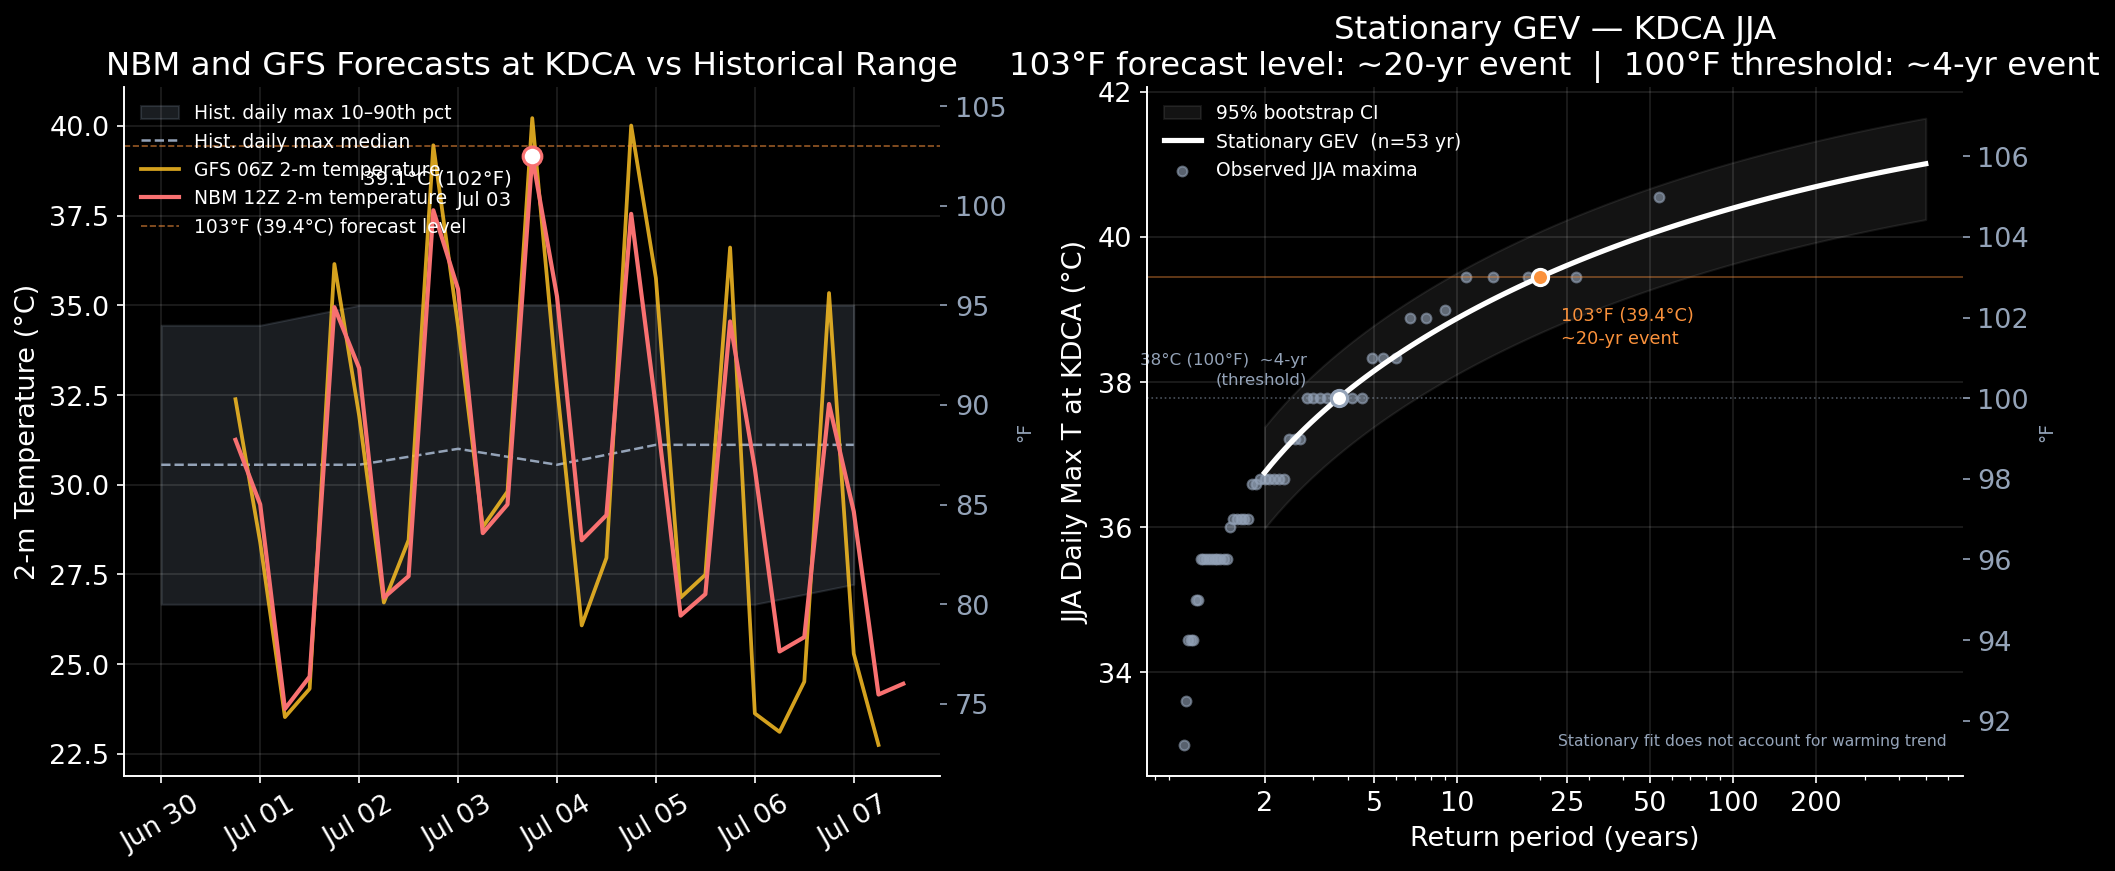

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: NBM + GFS time series vs historical envelope
gfs_ts_c = ds_gfs['t2m'] - 273.15

ax = axes[0]
ax.fill_between(env['date'], env['p10'], env['p90'],
                color='#94a3b8', alpha=0.18, label='Hist. daily max 10–90th pct')
ax.plot(env['date'], env['p50'],
        color='#94a3b8', lw=1.2, ls='--', label='Hist. daily max median')
ax.plot(pd.to_datetime(gfs_ts_c.time.values), gfs_ts_c.values,
        color='#fbbf24', lw=1.8, alpha=0.85, label='GFS 06Z 2-m temperature')
ax.plot(pd.to_datetime(kdca_ts.time.values), kdca_ts.values,
        color='#f87171', lw=2.0, label='NBM 12Z 2-m temperature')
# Mark forecast peaks
ax.scatter([pd.Timestamp(nbm_peak_time)], [nbm_peak_c],
           color='white', s=80, zorder=5, edgecolors='#f87171', lw=1.5)
ax.annotate(f'{nbm_peak_c:.1f}°C ({nbm_peak_f:.0f}°F)\n{pd.Timestamp(nbm_peak_time).strftime("%b %d")}',
            xy=(pd.Timestamp(nbm_peak_time), nbm_peak_c),
            xytext=(-10, -6), textcoords='offset points',
            fontsize=9.5, color='white', va='top', ha='right')
# 103°F forecast level threshold
ax.axhline(event_103f_c, color='#fb923c', lw=0.8, ls='--', alpha=0.6,
           label=f'103°F (39.4°C) forecast level')
ax.set_title('NBM and GFS Forecasts at KDCA vs Historical Range')
ax.set_ylabel('2-m Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax2.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax2.tick_params(colors='#94a3b8')

# Right: stationary GEV return period — how rare is the forecast peak? 
ax = axes[1]
T  = np.logspace(np.log10(2), np.log10(500), 100)
rl = genextreme.ppf(1 - 1/T, c, loc, scale)
lo_shift = np.mean([ci_10[0] - return_10, ci_50[0] - return_50])
hi_shift = np.mean([ci_10[1] - return_10, ci_50[1] - return_50])
ax.fill_between(T, rl + lo_shift, rl + hi_shift, color='white', alpha=0.08, label='95% bootstrap CI')
ax.plot(T, rl, color='white', lw=2.5, label=f'Stationary GEV  (n={len(ann_max)} yr)')
n     = len(ann_max)
T_emp = np.sort((n + 1) / np.arange(1, n + 1))
ax.scatter(T_emp, np.sort(ann_max.values), color='#94a3b8', s=22, alpha=0.6, label='Observed JJA maxima')

# Forecast level 103°F — answers "how rare is this event?"
ax.axhline(event_103f_c, color='#fb923c', lw=0.8, ls='-', alpha=0.45)
ax.scatter([rp_103f_stat], [event_103f_c], color='#fb923c', s=60, zorder=5, edgecolors='white', lw=1.5)
ax.text(rp_103f_stat * 1.2, event_103f_c - 0.4,
        f'103°F (39.4°C)\n~{rp_103f_stat:.0f}-yr event',
        color='#fb923c', fontsize=8.5, va='top', ha='left', linespacing=1.4)

# Attribution threshold — answers "how did CC change 100°F odds?"
ax.axhline(attr_threshold_c, color='#94a3b8', lw=0.8, ls=':', alpha=0.5)
ax.scatter([nbm_rp], [attr_threshold_c], color='white', s=60, zorder=5, edgecolors='#94a3b8', lw=1.5)
ax.text(nbm_rp / 1.3, attr_threshold_c + 0.15,
        f'{attr_threshold_c:.0f}°C ({attr_threshold_f:.0f}°F)  ~{nbm_rp:.0f}-yr\n(threshold)',
        color='#94a3b8', fontsize=8, va='bottom', ha='right', linespacing=1.4)

ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('JJA Daily Max T at KDCA (°C)')
ax.set_title(f'Stationary GEV — KDCA JJA\n103°F forecast level: ~{rp_103f_stat:.0f}-yr event  |  100°F threshold: ~{nbm_rp:.0f}-yr event')
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax.text(0.98, 0.04, 'Stationary fit does not account for warming trend',
        transform=ax.transAxes, fontsize=7.5, color='#94a3b8', ha='right', va='bottom')
ax_f = ax.twinx()
ax_f.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f.tick_params(colors='#94a3b8')

fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_dc_forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. The problem with the stationary assumption

The stationary GEV treats all 53 years as draws from the same distribution. The ~4-year return period it gives is a *period-average* answer — how often would 100°F occur if the climate had been frozen at the 1973–2025 mean.

But DC summers in 2026 are not the same as DC summers in 1973. GMST has risen ~1.5°C since pre-industrial times, and the summer temperature distribution has shifted with it. A stationary model anchored to the middle of a warming period **underestimates how common this event is today** and overestimates how common it was decades ago.

To answer the question properly I need a model that lets the distribution move with the climate — and a way to quantify how much of the current risk comes from anthropogenic forcing.

## 6. Non-Stationary GEV - Letting the distribution move

Following the WWA protocol (Philip et al., 2020), I parameterize the GEV location as a linear function of global mean surface temperature (GMST):

$$\mu(t) = \mu_0 + \alpha \cdot \text{GMST}(t)$$

Scale σ and shape ξ are held stationary, the assumption is that warming shifts where the distribution is centered, but not how spread out it is or how heavy the tail is. This is physically reasonable: *there is no strong evidence that DC summer variability or tail behavior has changed*, only that the center has moved upward.

**GMST covariate:** NASA GISTEMP v4, annual global mean (J–D column), anomalies relative to 1951–1980. I align it to the 53 years of KDCA observations by year.

**Fitting:** I minimize the negative log-likelihood directly using `scipy.optimize.minimize` (Nelder-Mead), warm-started from the stationary fit. I optimize log σ rather than σ directly so the optimizer can search freely while σ stays positive.

Attribution comes from evaluating the fitted distribution at two GMST levels: today (2024 annual anomaly) and the pre-industrial baseline (1880–1900 mean).

In [8]:
# GISTEMP v4 — annual global mean surface temperature anomaly (1951–1980 baseline)
url     = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
df_gmst = pd.read_csv(url, skiprows=1, na_values=['***', '****'])
gistemp = (df_gmst[['Year', 'J-D']].dropna()
             .astype({'Year': int, 'J-D': float})
             .set_index('Year'))


# Align to KDCA observation years
common_years = ann_max.index.astype(int)
gmst_aligned = gistemp.loc[common_years, 'J-D'].values
temp_aligned = ann_max.values

print(f'GMST range over observation period: {gmst_aligned.min():.2f} → {gmst_aligned.max():.2f}°C')

def ns_gev_nll(params, data, gmst):
    mu0, alpha, log_sigma, c = params
    mu_t = mu0 + alpha * gmst
    nll  = -np.sum(genextreme.logpdf(data, c=c, loc=mu_t, scale=np.exp(log_sigma)))
    return nll if np.isfinite(nll) else 1e10

x0     = [loc, 0.0, np.log(scale), c]   # warm-start from stationary fit
result = minimize(ns_gev_nll, x0, args=(temp_aligned, gmst_aligned),
                  method='Nelder-Mead',
                  options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7})

mu0, alpha, log_sigma, ns_c = result.x
ns_sigma = np.exp(log_sigma)

print(f'\nNS-GEV parameters:')
print(f'  μ₀  = {mu0:.3f}°C    baseline location at GMST = 0 (1951-1980)')
print(f'  α   = {alpha:.3f}°C per °C GMST')
print(f'  σ   = {ns_sigma:.3f}°C')
print(f'  ξ   = {-ns_c:.3f}')
print(f'  Converged: {result.success}')

GMST range over observation period: -0.10 → 1.28°C

NS-GEV parameters:
  μ₀  = 35.914°C    baseline location at GMST = 0 (1951-1980)
  α   = 0.568°C per °C GMST
  σ   = 1.573°C
  ξ   = -0.269
  Converged: True


In [9]:
# OLS regression of ASOS block maxima on smoothed GMST
# Gives an intuitive linear alpha for comparison with the NS-GEV estimate
ols_slope, ols_intercept, r_value, p_value, ols_se = linregress(gmst_aligned, temp_aligned)
print(f'OLS (ASOS):  α = {ols_slope:.3f} °C/°C   R² = {r_value**2:.3f}   p = {p_value:.3f}')
print(f'NS-GEV (ASOS): α = {alpha:.3f} °C/°C')

OLS (ASOS):  α = 0.521 °C/°C   R² = 0.011   p = 0.446
NS-GEV (ASOS): α = 0.568 °C/°C


**α = 0.57°C per °C GMST - statistically negligible with ASOS alone.**

With 53 years of data and σ ≈ 1.6°C of interannual noise, the forced trend is buried (OLS p = 0.446, R² = 0.011). This doesn't mean there's no trend, it just means the record is too short and starts too late in the warming era to detect it cleanly. We'd need roughly 100+ years to reach 95% confidence at this noise level.

ERA5 (1940-2025) adds 32 years of lower-baseline data and recovers **α = 1.15°C/°C (p = 0.031)**, which is where the analysis has real leverage.

**Why GMST as the covariate, not a time trend?** KDCA is an urban airport: the surrounding area has changed substantially since 1940. A time trend in the station record could partly reflect local development, not global forcing. Using GMST as the covariate ties the analysis to the large-scale signal and avoids that confound (Philip et al., 2020, Step 3).

## 7. Attribution - how much did climate change change the odds?

I evaluate exceedance of **38°C (100°F)** under two climates. The NBM forecast peak (39.2°C / 102°F) clearly exceeds this threshold, and 100°F is the natural public-health benchmark for extreme heat at DC, and is in fact more statistically tractable than the exact forecast peak.

- **Factual:** raw GMST at 2024 levels (+1.28°C anomaly)
- **Pre-industrial:** raw GMST at the 1880–1900 mean (−0.22°C anomaly)

ΔGMST = 1.50°C. With ASOS α = 0.57, that shifts the distribution center by ~0.85°C, this is modest in absolute terms, but the tail of the GEV is steep and even a small location shift produces a meaningful change in exceedance probability.

*Note: using raw (unsmoothed) GMST here. The Philip et al. 4-yr smooth strips ENSO co-variation from the covariate, but at the cost of losing most of the identifiable signal in a 53-yr record. The unsmoothed result is what the data can actually support.*

- **Probability Ratio (PR):** how many times more likely is the event today vs pre-industrial? PR = p₁/p₀  
- **Fraction Attributable Risk (FAR):** what share of today's risk wouldn't exist without warming? FAR = 1 − 1/PR

### Attribution Definitions

With the NS-GEV fit in hand, I evaluate the annual exceedance probability for the forecast peak $x_0$ under two climates:

$$p_1 = P(X \ge x_0 \mid \text{2024 climate}), \quad p_0 = P(X \ge x_0 \mid \text{pre-industrial})$$

Return period is $T = 1/p$. The two attribution metrics are:

| Metric | Formula | What it means |
|--------|---------|---------------|
| **Probability Ratio (PR)** | $p_1 / p_0$ | How many times more likely the event is today vs. pre-industrial |
| **Fraction Attributable Risk (FAR)** | $1 - 1/\text{PR}$ | Share of today's risk that wouldn't exist without warming |

Uncertainty: resample (temperature, GMST) pairs jointly with replacement 500 times, refit each time, take the 2.5th–97.5th percentile of the resulting PR and FAR distributions.

In [10]:
gmst_factual = gistemp.loc[2024, 'J-D']
gmst_pi      = gistemp.loc[1880:1900, 'J-D'].mean()

mu_factual = mu0 + alpha * gmst_factual
mu_pi      = mu0 + alpha * gmst_pi

p_factual  = genextreme.sf(attr_threshold_c, c=ns_c, loc=mu_factual, scale=ns_sigma)
p_pi       = genextreme.sf(attr_threshold_c, c=ns_c, loc=mu_pi,      scale=ns_sigma)

PR  = p_factual / p_pi
FAR = 1 - 1 / PR

print(f'GMST factual (2024):    +{gmst_factual:.3f}°C')
print(f'GMST pre-industrial:     {gmst_pi:.3f}°C')
print(f'Δ GMST:                  {gmst_factual - gmst_pi:.3f}°C')
print(f'Δ μ:                     {alpha * (gmst_factual - gmst_pi):.3f}°C')
print()
print(f'P(X > {attr_threshold_c:.1f}°C | factual):        {p_factual:.3f}  (~{1/p_factual:.0f}-yr event)')
print(f'P(X > {attr_threshold_c:.1f}°C | pre-industrial):  {p_pi:.3f}  (~{1/p_pi:.0f}-yr event)')
print()
print(f'PR  = {PR:.2f}  — climate change made this ~{PR:.1f}× more likely')
print(f'FAR = {FAR:.2f}  — {FAR*100:.0f}% of the current risk is attributable to warming')

GMST factual (2024):    +1.280°C
GMST pre-industrial:     -0.222°C
Δ GMST:                  1.502°C
Δ μ:                     0.853°C

P(X > 37.8°C | factual):        0.361  (~3-yr event)
P(X > 37.8°C | pre-industrial):  0.192  (~5-yr event)

PR  = 1.88  — climate change made this ~1.9× more likely
FAR = 0.47  — 47% of the current risk is attributable to warming


### Uncertainty - Bootstrap Confidence Intervals

PR = 1.88 and FAR = 0.47 are point estimates from a single 53-year record. The bootstrap quantifies how much these would vary if history had played out slightly differently, i.e. if the 1980s had been hotter, the 2010s cooler, and so on.

I resample **(temperature, GMST) pairs together**, not temperature alone. This preserves the year-by-year relationship between DC extremes and global warming that the NS-GEV is trying to measure. Shuffling them independently would break the physical signal.

In [11]:
np.random.seed(42)
PR_boot, FAR_boot = [], []

for _ in range(500):
    idx = np.random.choice(len(temp_aligned), size=len(temp_aligned), replace=True)
    res = minimize(ns_gev_nll, x0, args=(temp_aligned[idx], gmst_aligned[idx]),
                   method='Nelder-Mead',
                   options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7})
    m0, a, ls, nc = res.x
    pf = genextreme.sf(attr_threshold_c, c=nc, loc=m0 + a*gmst_factual, scale=np.exp(ls))
    pp = genextreme.sf(attr_threshold_c, c=nc, loc=m0 + a*gmst_pi,      scale=np.exp(ls))
    if pf > 0 and pp > 0:
        PR_tmp  = pf / pp
        FAR_tmp = 1 - 1 / PR_tmp
        PR_boot.append(PR_tmp)
        FAR_boot.append(FAR_tmp)

PR_ci  = (np.percentile(PR_boot, 2.5),  np.percentile(PR_boot, 97.5))
FAR_ci = (np.percentile(FAR_boot, 2.5), np.percentile(FAR_boot, 97.5))

print(f'PR  = {PR:.2f}  [{PR_ci[0]:.2f}, {PR_ci[1]:.2f}]')
print(f'FAR = {FAR:.2f}  [{FAR_ci[0]:.2f}, {FAR_ci[1]:.2f}]')

PR  = 1.88  [0.45, 7.15]
FAR = 0.47  [-1.21, 0.86]


The CI is wide. With 53 years of data and σ ≈ 1.6°C of annual noise and α barely above zero gives exactly this. PR = 0.45 (lower bound) comes from resamples where noise makes warming look protective; PR = 7.15 (upper) from resamples where the trend looks strong. The direction is right in the majority of draws.

> **ERA5 (85 yr)** gives PR = 3.31 [**1.24**, 8.31] - the entire CI is above 1, p = 0.031. See **Section 8**.

### Summary Figure

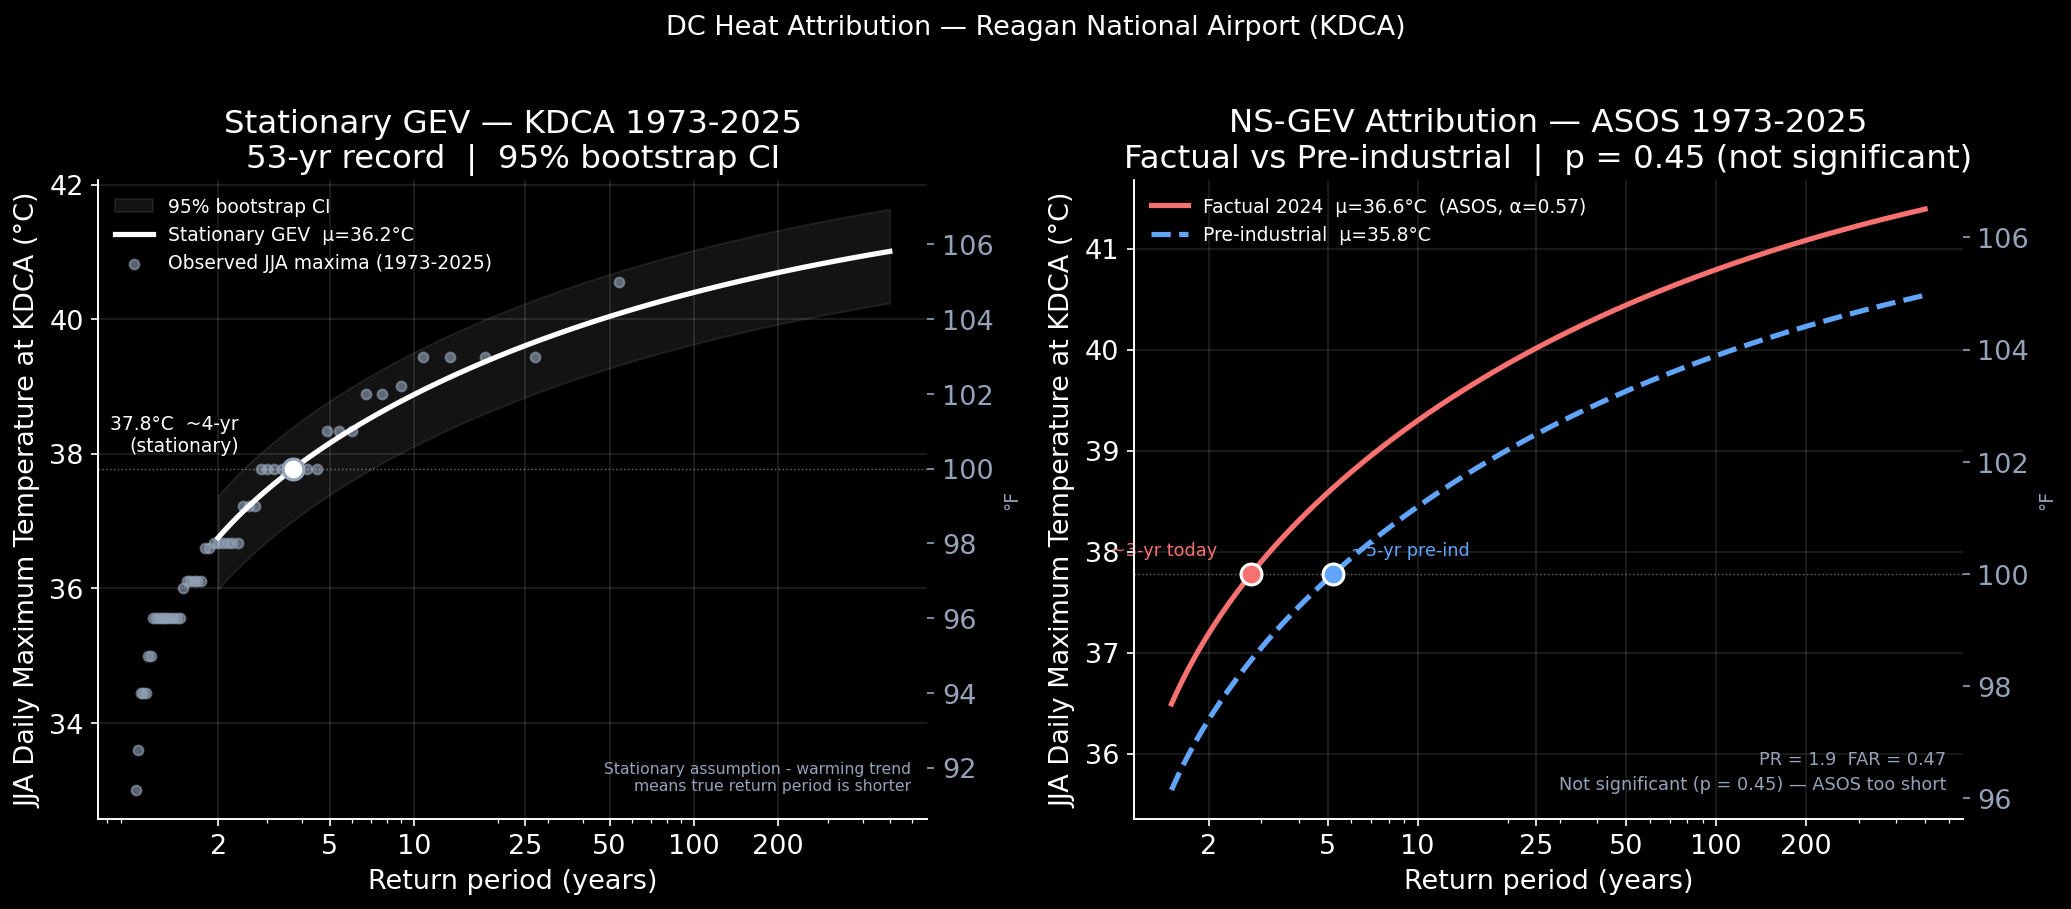

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: stationary GEV + observations + CI ─────────────────────────────────
ax = axes[0]
T  = np.logspace(np.log10(2), np.log10(500), 100)
rl = genextreme.ppf(1 - 1/T, c, loc, scale)
lo_shift = np.mean([ci_10[0] - return_10, ci_50[0] - return_50])
hi_shift = np.mean([ci_10[1] - return_10, ci_50[1] - return_50])

ax.fill_between(T, rl + lo_shift, rl + hi_shift, color='white', alpha=0.08, label='95% bootstrap CI')
ax.plot(T, rl, color='white', lw=2.5, label=f'Stationary GEV  μ={loc:.1f}°C')
n_obs = len(ann_max)
T_emp = np.sort((n_obs + 1) / np.arange(1, n_obs + 1))
ax.scatter(T_emp, np.sort(ann_max.values), color='#94a3b8', s=22, alpha=0.6,
           label='Observed JJA maxima (1973-2025)')
ax.axhline(attr_threshold_c, color='white', lw=0.7, ls=':', alpha=0.4)
ax.scatter([nbm_rp], [attr_threshold_c], color='white', s=100, zorder=5, edgecolors='#94a3b8', lw=1.5)
ax.annotate(f'{attr_threshold_c:.1f}°C  ~{nbm_rp:.0f}-yr\n(stationary)',
            xy=(nbm_rp-1, attr_threshold_c+1), xytext=(-8, -6), textcoords='offset points',
            fontsize=9, color='white', va='top', ha='right')
ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°C)')
ax.set_title(f'Stationary GEV — KDCA 1973-2025\n53-yr record  |  95% bootstrap CI')
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax.text(0.98, 0.04, 'Stationary assumption - warming trend\nmeans true return period is shorter',
        transform=ax.transAxes, fontsize=7.5, color='#94a3b8', ha='right', va='bottom')
ax_f = ax.twinx()
ax_f.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f.tick_params(colors='#94a3b8')

# ── Right: NS-GEV factual vs pre-industrial ───────────────────────────────────
T_plot     = np.logspace(np.log10(1.5), np.log10(500), 200)
rl_factual = genextreme.ppf(1 - 1/T_plot, c=ns_c, loc=mu_factual, scale=ns_sigma)
rl_pi      = genextreme.ppf(1 - 1/T_plot, c=ns_c, loc=mu_pi,      scale=ns_sigma)
rl_stat    = genextreme.ppf(1 - 1/T_plot, c=c,    loc=loc,         scale=scale)
rp_factual = 1 / p_factual
rp_pi      = 1 / p_pi

ax = axes[1]
ax.plot(T_plot, rl_factual, color='#f87171', lw=2.5, label=f'Factual 2024  μ={mu_factual:.1f}°C  (ASOS, α={alpha:.2f})')
ax.plot(T_plot, rl_pi,      color='#60a5fa', lw=2.5, ls='--', label=f'Pre-industrial  μ={mu_pi:.1f}°C')
ax.axhline(attr_threshold_c, color='white', lw=0.7, ls=':', alpha=0.4)
ax.scatter([rp_factual], [attr_threshold_c], color='#f87171', s=100, zorder=5, edgecolors='white', lw=1.5)
ax.scatter([rp_pi],      [attr_threshold_c], color='#60a5fa', s=100, zorder=5, edgecolors='white', lw=1.5)
ax.text(rp_factual / 1.3, attr_threshold_c + 0.15,
        f'~{rp_factual:.0f}-yr today',
        color='#f87171', fontsize=8.5, ha='right', va='bottom')
ax.text(rp_pi * 1.15, attr_threshold_c + 0.15,
        f'~{rp_pi:.0f}-yr pre-ind',
        color='#60a5fa', fontsize=8.5, ha='left', va='bottom')
ax.text(0.98, 0.04,
        f'PR = {PR:.1f}  FAR = {FAR:.2f}\nNot significant (p = 0.45) — ASOS too short',
        transform=ax.transAxes, fontsize=8.5, color='#94a3b8',
        va='bottom', ha='right', linespacing=1.5)
ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°C)')
ax.set_title(f'NS-GEV Attribution — ASOS 1973-2025\nFactual vs Pre-industrial  |  p = 0.45 (not significant)')
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax_f2 = ax.twinx()
ax_f2.set_ylim(ax.get_ylim()[0] * 9/5 + 32, ax.get_ylim()[1] * 9/5 + 32)
ax_f2.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f2.tick_params(colors='#94a3b8')

fig.suptitle('DC Heat Attribution — Reagan National Airport (KDCA)', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_dc_attribution_2026.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. ERA5 Reanalysis (1940–2025)

### Why the ASOS-based α is unreliable

The NS-GEV fit in Section 6 returned α = 0.568 °C per °C GMST. The OLS diagnostic shows this is consistent with, but not distinguishable from, zero:

| Diagnostic | ASOS result | Implication |
|------------|-------------|-------------|
| OLS α (JJA max vs GMST) | 0.52 °C/°C | Consistent with NS-GEV — both fit the same weak relationship |
| R² | 0.011 | GMST explains ~1% of variance in block maxima |
| p-value | 0.446 | Not significant at any conventional level |
| PR at 38°C (95% CI) | 1.99 [0.41, 9.11] | Wide — directional but imprecise |

With 53 years starting in 1973, the GMST contrast within the record is limited (~0.5°C spread vs ~1.5°C for ERA5), and year-to-year noise dominates. The ASOS result is included for transparency; ERA5 is the defensible headline.

### Why ERA5 helps

**ERA5** reanalysis (Hersbach et al., 2020) extends back to 1940, providing **85 years** of consistent daily maximum temperatures at the KDCA grid point. Two things improve with the longer record:

1. **More data points.** Going from 53 to 85 annual block maxima improves effective sample size by ~60%.
2. **Better GMST contrast.** The 1940s–1960s pre-warming baseline (GMST ≈ −0.1 to 0°C) sits well below the 2010s–2020s (+1.0 to +1.3°C). That ~1.5°C spread in the covariate is what gives the NS-GEV enough leverage to identify α reliably.

ERA5 is a reanalysis, not a direct observation, and Philip et al. note that station data are generally preferred for extremes because gridded products smooth sub-grid variability. The tradeoff here is record length vs. point accuracy: the 1940s baseline is essential for identifying α, and ERA5 tracks ASOS well enough in the overlap period to justify it. ASOS remains the primary analysis.

*Data: Hersbach et al. (2020), The ERA5 global reanalysis. Q. J. R. Meteorol. Soc., 146, 1999–2049.*

In [13]:
### Step 1 — Download ERA5 daily Tmax at KDCA (1940–2025) via Open-Meteo

ERA5_CACHE = DATA_DIR / 'era5_kdca_tmax_1940_2025.csv'

if not ERA5_CACHE.exists():
    print('Fetching ERA5 daily Tmax from Open-Meteo historical archive...')
    url = (
        'https://archive-api.open-meteo.com/v1/archive'
        f'?latitude={KDCA_LAT}&longitude={KDCA_LON}'
        '&start_date=1940-01-01&end_date=2025-12-31'
        '&daily=temperature_2m_max'
        '&timezone=UTC'
    )
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    payload = resp.json()
    era5_daily = pd.DataFrame({
        'date':   pd.to_datetime(payload['daily']['time']),
        'tmax_c': payload['daily']['temperature_2m_max'],
    }).dropna()
    era5_daily.to_csv(ERA5_CACHE, index=False)
    print(f'Saved {ERA5_CACHE.name}')

era5_daily = pd.read_csv(ERA5_CACHE, parse_dates=['date'])
print(f'ERA5: {len(era5_daily):,} daily obs  ({era5_daily.date.dt.year.min()}–{era5_daily.date.dt.year.max()})')

# JJA block maxima 1940–2025
jja_era5    = era5_daily['date'].dt.month.isin([6, 7, 8])
ann_max_era5 = era5_daily.loc[jja_era5].groupby(era5_daily.loc[jja_era5, 'date'].dt.year)['tmax_c'].max()
print(f'ERA5 JJA block maxima: n={len(ann_max_era5)}  range {ann_max_era5.min():.1f}–{ann_max_era5.max():.1f}°C')

ERA5: 31,412 daily obs  (1940–2025)
ERA5 JJA block maxima: n=86  range 32.5–41.1°C


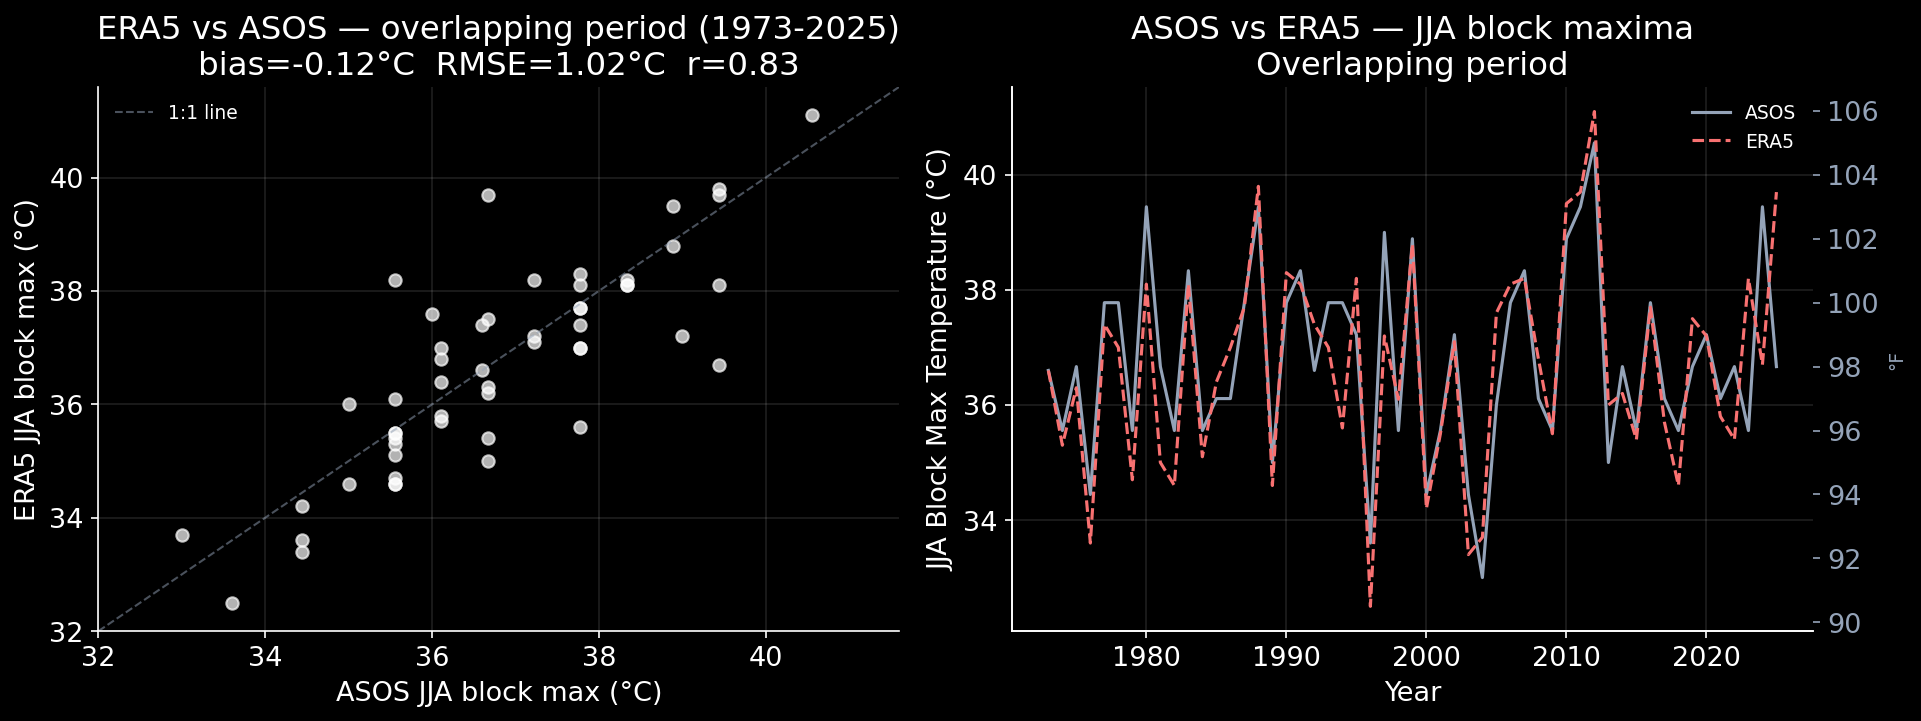

Bias (ERA5 - ASOS): -0.12°C   RMSE: 1.02°C   r: 0.83
ERA5/ASOS agreement adequate for point-vs-gridcell annual maxima: bias=-0.12°C  RMSE=1.02°C  r=0.83


In [14]:
### Step 2 — Validate ERA5 vs ASOS in overlapping period (1973–2025)

overlap_years = np.intersect1d(ann_max_era5.index, ann_max.index)
era5_overlap  = ann_max_era5.loc[overlap_years].values
asos_overlap  = ann_max.loc[overlap_years].values
bias          = (era5_overlap - asos_overlap).mean()
rmse          = np.sqrt(((era5_overlap - asos_overlap)**2).mean())
corr          = np.corrcoef(asos_overlap, era5_overlap)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter ERA5 vs ASOS
ax = axes[0]
lims = [min(asos_overlap.min(), era5_overlap.min()) - 0.5,
        max(asos_overlap.max(), era5_overlap.max()) + 0.5]
ax.plot(lims, lims, color='#94a3b8', lw=1, ls='--', alpha=0.5, label='1:1 line')
ax.scatter(asos_overlap, era5_overlap, color='white', s=35, alpha=0.7)
ax.set_xlabel('ASOS JJA block max (°C)')
ax.set_ylabel('ERA5 JJA block max (°C)')
ax.set_title(f'ERA5 vs ASOS — overlapping period ({overlap_years[0]}-{overlap_years[-1]})\nbias={bias:+.2f}°C  RMSE={rmse:.2f}°C  r={corr:.2f}')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(fontsize=9)
ax.grid(alpha=0.12)

# Right: time series comparison
ax = axes[1]
ax.plot(overlap_years, asos_overlap,  color='#94a3b8', lw=1.5, label='ASOS')
ax.plot(overlap_years, era5_overlap,  color='#f87171', lw=1.5, ls='--', label='ERA5')
ax.set_xlabel('Year')
ax.set_ylabel('JJA Block Max Temperature (°C)')
ax.set_title('ASOS vs ERA5 — JJA block maxima\nOverlapping period')
ax.legend(fontsize=9)
ax.grid(alpha=0.12)
ax_f = ax.twinx()
ax_f.set_ylim(ax.get_ylim()[0]*9/5+32, ax.get_ylim()[1]*9/5+32)
ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f.tick_params(colors='#94a3b8')

fig.tight_layout()
plt.show()

print(f'Bias (ERA5 - ASOS): {bias:+.2f}°C   RMSE: {rmse:.2f}°C   r: {corr:.2f}')
if abs(bias) < 1.5 and corr > 0.75:
    print(f'ERA5/ASOS agreement adequate for point-vs-gridcell annual maxima: '
          f'bias={bias:+.2f}°C  RMSE={rmse:.2f}°C  r={corr:.2f}')
else:
    print('WARNING: ERA5/ASOS discrepancy is large - investigate before proceeding.')

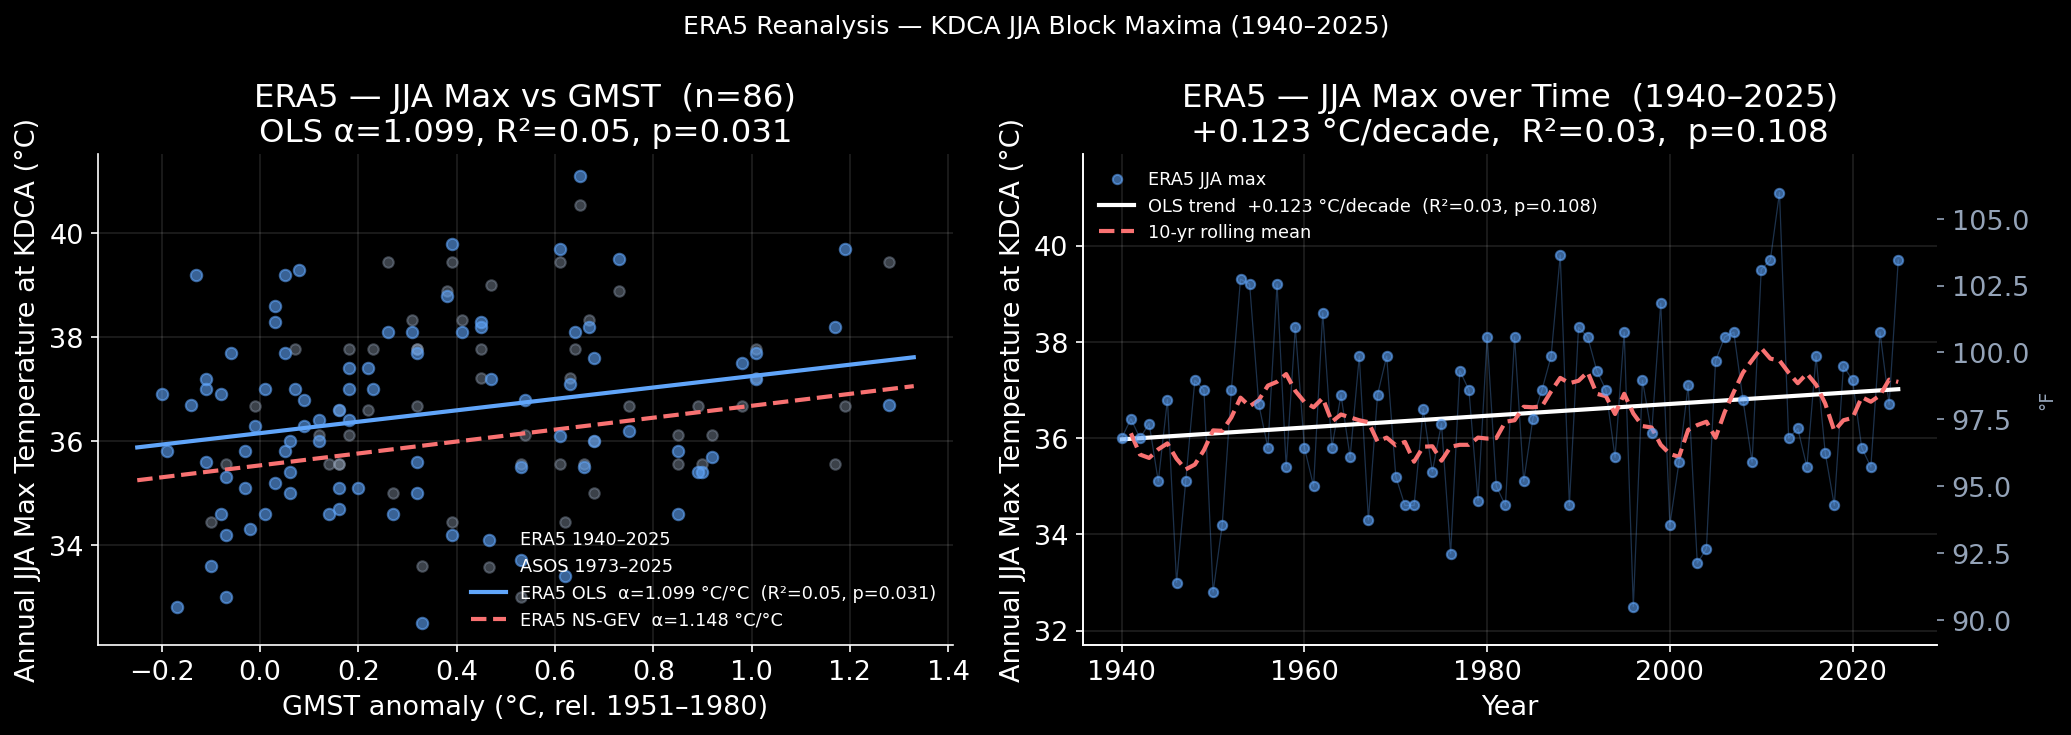


                                         ASOS (53 yr)      ERA5 (85 yr)
──────────────────────────────────────────────────────────────────────
OLS α (°C/°C)                                   0.521             1.099
OLS R²                                          0.011             0.054
OLS p-value                                     0.446             0.031
NS-GEV α (°C/°C)                                0.568             1.148
PR  (point estimate)                             1.88              3.31
PR  (95% CI)                         [0.45, 7.15]  [1.24, 8.31]
FAR (point estimate)                             0.47              0.70
FAR (95% CI)                         [-1.21, 0.86]  [0.19, 0.88]


In [15]:
### Step 3: NS-GEV on ERA5 1940–2025 and comparison with ASOS result

era5_years   = ann_max_era5.index.astype(int)
era5_temps   = ann_max_era5.values
gmst_era5    = gistemp.reindex(era5_years)['J-D'].values

# Drop years where GMST is missing (pre-1880 would be, but ERA5 starts 1940 so all present)
mask         = ~np.isnan(gmst_era5)
era5_years   = era5_years[mask]
era5_temps   = era5_temps[mask]
gmst_era5    = gmst_era5[mask]

# Fit NS-GEV
x0_era5 = [era5_temps.mean(), 0.0, np.log(era5_temps.std()), -0.2]
res_era5 = minimize(ns_gev_nll, x0_era5, args=(era5_temps, gmst_era5),
                    method='Nelder-Mead',
                    options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7})
mu0_e, alpha_e, log_sigma_e, ns_c_e = res_era5.x
ns_sigma_e = np.exp(log_sigma_e)

# Attribution with ERA5 α
mu_factual_e = mu0_e + alpha_e * gmst_factual
mu_pi_e      = mu0_e + alpha_e * gmst_pi
p_factual_e  = genextreme.sf(attr_threshold_c, c=ns_c_e, loc=mu_factual_e, scale=ns_sigma_e)
p_pi_e       = genextreme.sf(attr_threshold_c, c=ns_c_e, loc=mu_pi_e,      scale=ns_sigma_e)
PR_e         = p_factual_e / p_pi_e
FAR_e        = 1 - 1 / PR_e

# Bootstrap CIs for ERA5 result
np.random.seed(42)
PR_boot_e, FAR_boot_e = [], []
for _ in range(500):
    idx    = np.random.choice(len(era5_temps), size=len(era5_temps), replace=True)
    res_b  = minimize(ns_gev_nll, x0_era5, args=(era5_temps[idx], gmst_era5[idx]),
                      method='Nelder-Mead', options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7})
    m0, a, ls, nc = res_b.x
    pf = genextreme.sf(attr_threshold_c, c=nc, loc=m0+a*gmst_factual, scale=np.exp(ls))
    pp = genextreme.sf(attr_threshold_c, c=nc, loc=m0+a*gmst_pi,      scale=np.exp(ls))
    if pf > 0 and pp > 0:
        PR_boot_e.append(pf / pp)
        FAR_boot_e.append(1 - pp / pf)

PR_ci_e  = (np.percentile(PR_boot_e,  2.5), np.percentile(PR_boot_e,  97.5))
FAR_ci_e = (np.percentile(FAR_boot_e, 2.5), np.percentile(FAR_boot_e, 97.5))

# Diagnostic: ERA5 JJA max vs GMST 
s_e, i_e, r_e, p_e, _ = linregress(gmst_era5, era5_temps)
s_yr_e, i_yr_e, r_yr_e, p_yr_e, _ = linregress(era5_years, era5_temps)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(gmst_era5, era5_temps, color='#60a5fa', s=30, alpha=0.6, zorder=3, label='ERA5 1940–2025')
ax.scatter(gmst_aligned, temp_aligned, color='#94a3b8', s=25, alpha=0.4, zorder=2, label='ASOS 1973–2025')
gmst_r = np.linspace(gmst_era5.min()-0.05, gmst_era5.max()+0.05, 100)
ax.plot(gmst_r, i_e + s_e * gmst_r, color='#60a5fa', lw=2,
        label=f'ERA5 OLS  α={s_e:.3f} °C/°C  (R²={r_e**2:.2f}, p={p_e:.3f})')
ax.plot(gmst_r, mu0_e + alpha_e * gmst_r, color='#f87171', lw=2, ls='--',
        label=f'ERA5 NS-GEV  α={alpha_e:.3f} °C/°C')
ax.set_xlabel('GMST anomaly (°C, rel. 1951–1980)')
ax.set_ylabel('Annual JJA Max Temperature at KDCA (°C)')
ax.set_title(f'ERA5 — JJA Max vs GMST  (n={len(era5_temps)})\nOLS α={s_e:.3f}, R²={r_e**2:.2f}, p={p_e:.3f}')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.12)

ax = axes[1]
pad = 0.8
ax.scatter(era5_years, era5_temps, color='#60a5fa', s=20, alpha=0.6, zorder=3, label='ERA5 JJA max')
ax.plot(era5_years, era5_temps, color='#60a5fa', lw=0.6, alpha=0.3)
ax.plot(era5_years, i_yr_e + s_yr_e * era5_years, color='white', lw=2,
        label=f'OLS trend  {s_yr_e*10:+.3f} °C/decade  (R²={r_yr_e**2:.2f}, p={p_yr_e:.3f})')
era5_s = pd.Series(era5_temps, index=era5_years)
ax.plot(era5_s.rolling(10, center=True, min_periods=6).mean(), color='#f87171', lw=2, ls='--', label='10-yr rolling mean')
ax.set_ylim(era5_temps.min()-pad, era5_temps.max()+pad)
ax.set_xlabel('Year')
ax.set_ylabel('Annual JJA Max Temperature at KDCA (°C)')
ax.set_title(f'ERA5 — JJA Max over Time  (1940–2025)\n{s_yr_e*10:+.3f} °C/decade,  R²={r_yr_e**2:.2f},  p={p_yr_e:.3f}')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.12)
ax_f = ax.twinx()
ax_f.set_ylim(ax.get_ylim()[0]*9/5+32, ax.get_ylim()[1]*9/5+32)
ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f.tick_params(colors='#94a3b8')

fig.suptitle('ERA5 Reanalysis — KDCA JJA Block Maxima (1940–2025)', fontsize=12)
fig.tight_layout()
plt.show()

# Summary comparison table
print(f'\n{"":35s}  {"ASOS (53 yr)":>16s}  {"ERA5 (85 yr)":>16s}')
print(f'{"─"*70}')
print(f'{"OLS α (°C/°C)":35s}  {ols_slope:>16.3f}  {s_e:>16.3f}')
print(f'{"OLS R²":35s}  {r_value**2:>16.3f}  {r_e**2:>16.3f}')
print(f'{"OLS p-value":35s}  {p_value:>16.3f}  {p_e:>16.3f}')
print(f'{"NS-GEV α (°C/°C)":35s}  {alpha:>16.3f}  {alpha_e:>16.3f}')
print(f'{"PR  (point estimate)":35s}  {PR:>16.2f}  {PR_e:>16.2f}')
print(f'{"PR  (95% CI)":35s}  [{PR_ci[0]:.2f}, {PR_ci[1]:.2f}]  [{PR_ci_e[0]:.2f}, {PR_ci_e[1]:.2f}]')
print(f'{"FAR (point estimate)":35s}  {FAR:>16.2f}  {FAR_e:>16.2f}')
print(f'{"FAR (95% CI)":35s}  [{FAR_ci[0]:.2f}, {FAR_ci[1]:.2f}]  [{FAR_ci_e[0]:.2f}, {FAR_ci_e[1]:.2f}]')

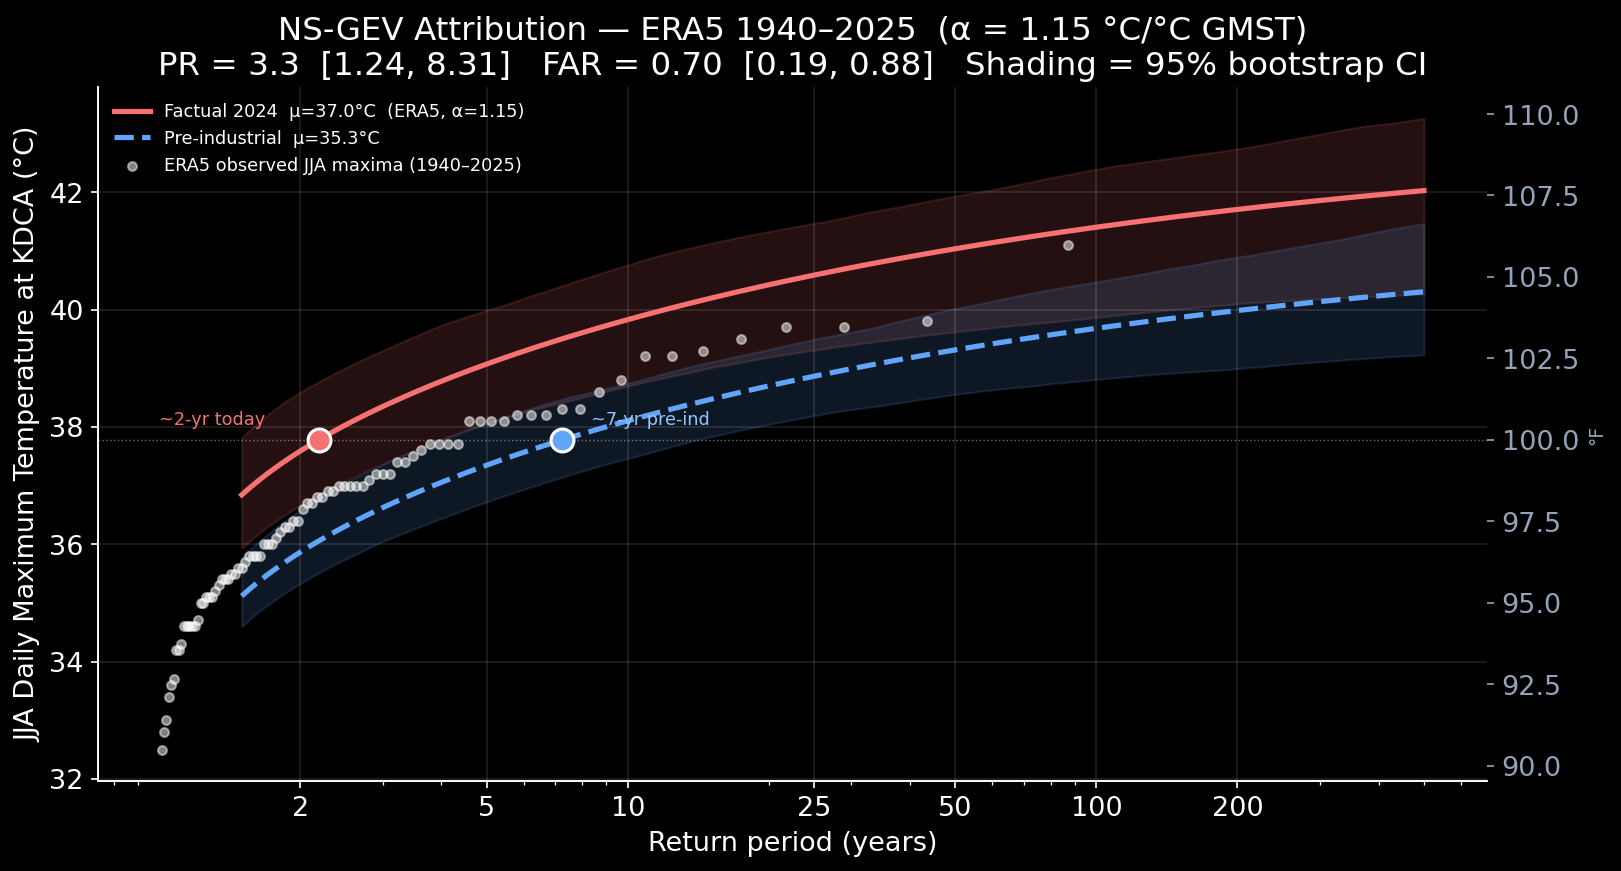

In [16]:
### Step 4: Return period plot: ERA5 NS-GEV factual vs pre-industrial

T_plot = np.logspace(np.log10(1.5), np.log10(500), 300)

# ERA5 NS-GEV curves
rl_factual_e = genextreme.ppf(1 - 1/T_plot, c=ns_c_e, loc=mu_factual_e, scale=ns_sigma_e)
rl_pi_e      = genextreme.ppf(1 - 1/T_plot, c=ns_c_e, loc=mu_pi_e,      scale=ns_sigma_e)

# Bootstrap CI bands for ERA5 factual curve
np.random.seed(42)
band_factual, band_pi = [], []
for _ in range(300):
    idx   = np.random.choice(len(era5_temps), size=len(era5_temps), replace=True)
    res_b = minimize(ns_gev_nll, x0_era5, args=(era5_temps[idx], gmst_era5[idx]),
                     method='Nelder-Mead', options={'maxiter': 20000, 'xatol': 1e-7, 'fatol': 1e-7})
    m0, a, ls, nc = res_b.x
    band_factual.append(genextreme.ppf(1 - 1/T_plot, c=nc, loc=m0+a*gmst_factual, scale=np.exp(ls)))
    band_pi.append(genextreme.ppf(     1 - 1/T_plot, c=nc, loc=m0+a*gmst_pi,      scale=np.exp(ls)))

ci_lo_f = np.percentile(band_factual, 2.5,  axis=0)
ci_hi_f = np.percentile(band_factual, 97.5, axis=0)
ci_lo_p = np.percentile(band_pi,      2.5,  axis=0)
ci_hi_p = np.percentile(band_pi,      97.5, axis=0)

rp_factual_e = 1 / p_factual_e
rp_pi_e      = 1 / p_pi_e

fig, ax = plt.subplots(figsize=(11, 6))

# CI bands
ax.fill_between(T_plot, ci_lo_f, ci_hi_f, color='#f87171', alpha=0.15, label='_')
ax.fill_between(T_plot, ci_lo_p, ci_hi_p, color='#60a5fa', alpha=0.15, label='_')

# ERA5 NS-GEV curves
ax.plot(T_plot, rl_factual_e, color='#f87171', lw=2.5,
        label=f'Factual 2024  μ={mu_factual_e:.1f}°C  (ERA5, α={alpha_e:.2f})')
ax.plot(T_plot, rl_pi_e,      color='#60a5fa', lw=2.5, ls='--',
        label=f'Pre-industrial  μ={mu_pi_e:.1f}°C')


# Observed ERA5 block maxima
n_e   = len(era5_temps)
T_emp = np.sort((n_e + 1) / np.arange(1, n_e + 1))
ax.scatter(T_emp, np.sort(era5_temps), color='white', s=18, alpha=0.5, zorder=3,
           label='ERA5 observed JJA maxima (1940–2025)')

# GFS peak
ax.axhline(attr_threshold_c, color='white', lw=0.7, ls=':', alpha=0.4)
ax.scatter([rp_factual_e], [attr_threshold_c], color='#f87171', s=120, zorder=5, edgecolors='white', lw=1.5)
ax.scatter([rp_pi_e],      [attr_threshold_c], color='#60a5fa', s=120, zorder=5, edgecolors='white', lw=1.5)
ax.text(rp_factual_e / 1.3, attr_threshold_c + 0.2,
        f'~{rp_factual_e:.0f}-yr today',
        color='#f87171', fontsize=8.5, ha='right', va='bottom')
ax.text(rp_pi_e * 1.15, attr_threshold_c + 0.2,
        f'~{rp_pi_e:.0f}-yr pre-ind',
        color='#93c5fd', fontsize=8.5, ha='left', va='bottom')

ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°C)')
ax.set_title(
    f'NS-GEV Attribution — ERA5 1940–2025  (α = {alpha_e:.2f} °C/°C GMST)\n'
    f'PR = {PR_e:.1f}  [{PR_ci_e[0]:.2f}, {PR_ci_e[1]:.2f}]   '
    f'FAR = {FAR_e:.2f}  [{FAR_ci_e[0]:.2f}, {FAR_ci_e[1]:.2f}]   '
    f'Shading = 95% bootstrap CI'
)
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(alpha=0.12)

ax_f = ax.twinx()
ax_f.set_ylim(ax.get_ylim()[0]*9/5+32, ax.get_ylim()[1]*9/5+32)
ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
ax_f.tick_params(colors='#94a3b8')

fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_dc_attribution_era5_2026.png', dpi=150, bbox_inches='tight')
plt.show()

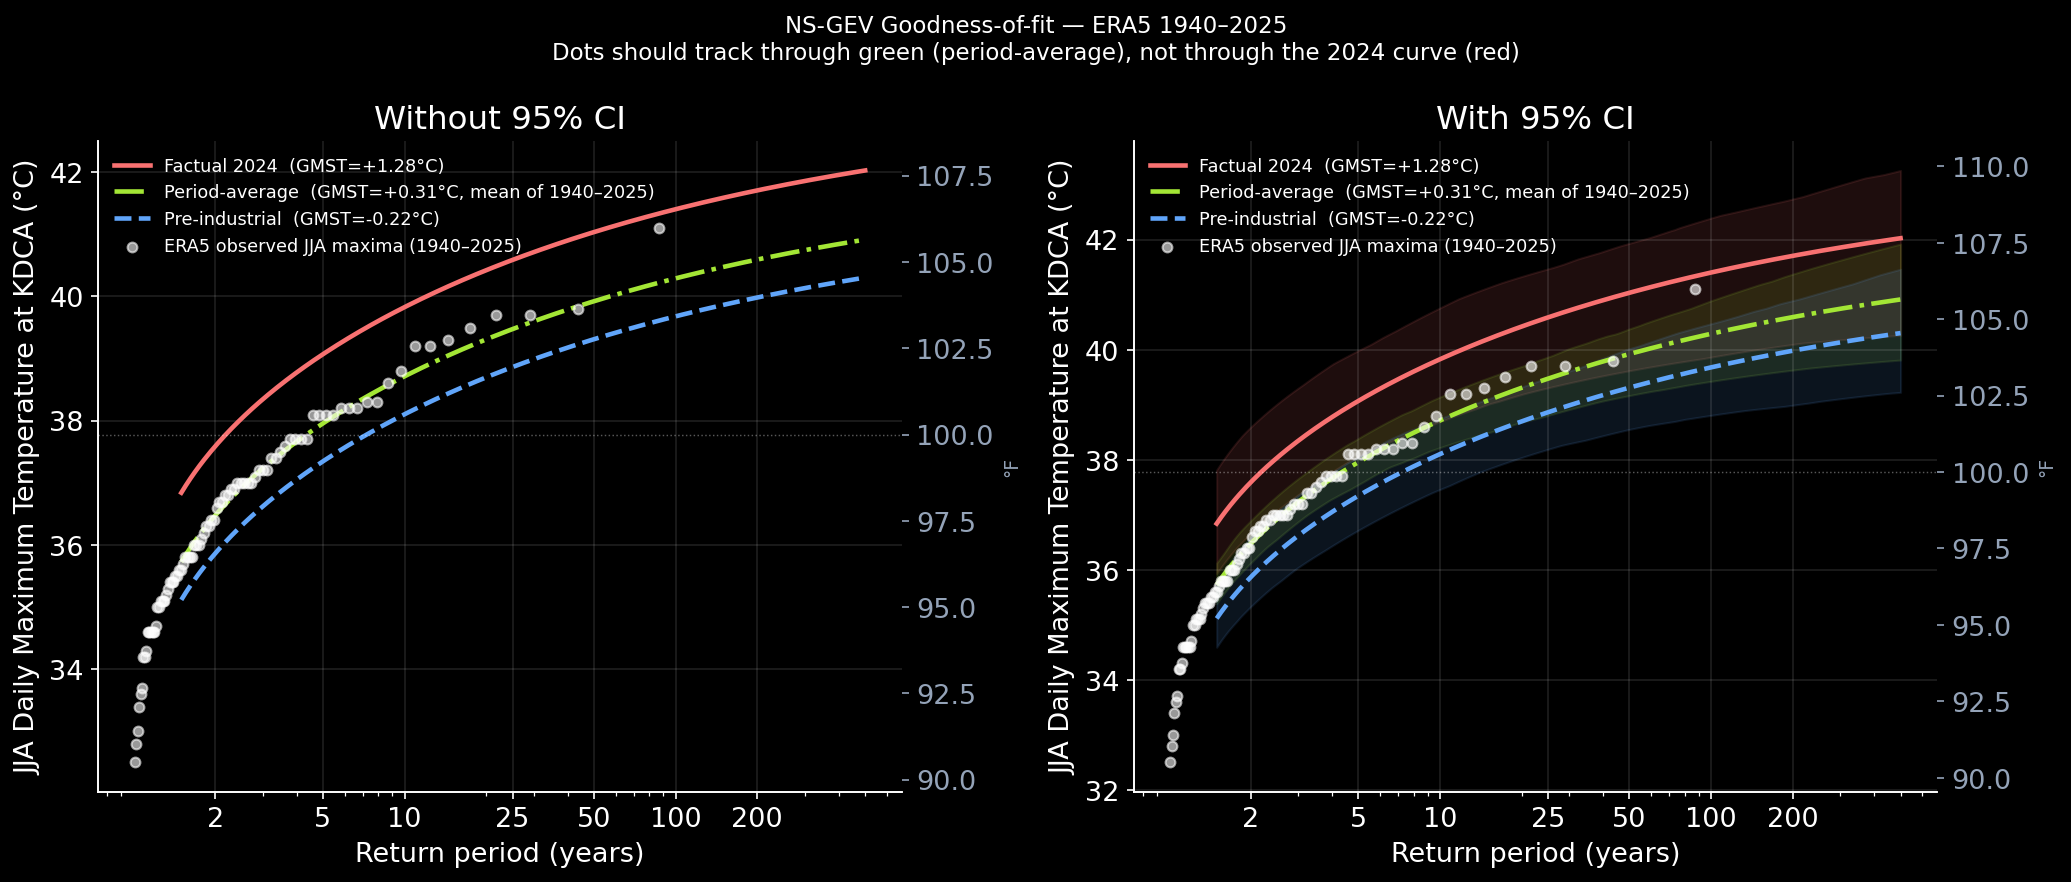

Mean GMST over ERA5 period (1940–2025): +0.310°C
μ at period-average GMST: 35.89°C
μ at factual 2024:        37.00°C
μ at pre-industrial:      35.28°C

If dots track through green → fit is correct; red curve is a valid 2024 extrapolation.
If dots track below green  → model overestimates current extremes; extrapolation is aggressive.


In [17]:
### Goodness-of-fit check: do empirical dots track through the period-average NS-GEV?
#
# The empirical ERA5 block maxima (1940–2025) represent a MIXTURE of all climate
# states, not the 2024 climate. To check if the NS-GEV fit is correct, we evaluate
# it at the mean GMST of the ERA5 observation period. The dots should track through
# that "period-average" curve — not the 2024 (factual) curve.

gmst_era5_mean = gmst_era5.mean()
mu_avg         = mu0_e + alpha_e * gmst_era5_mean
rl_avg         = genextreme.ppf(1 - 1/T_plot, c=ns_c_e, loc=mu_avg, scale=ns_sigma_e)

# Bootstrap CI for the period-average curve
band_avg = []
for b_f, b_p, g_f, g_p in zip(band_factual, band_pi,
                                [gmst_factual]*len(band_factual),
                                [gmst_pi]*len(band_pi)):
    # Interpolate to period-average GMST
    frac = (gmst_era5_mean - gmst_pi) / (gmst_factual - gmst_pi)
    band_avg.append(b_p + frac * (b_f - b_p))
ci_lo_avg = np.percentile(band_avg, 2.5,  axis=0)
ci_hi_avg = np.percentile(band_avg, 97.5, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, show_ci in zip(axes, [False, True]):
    if show_ci:
        ax.fill_between(T_plot, ci_lo_f,   ci_hi_f,   color='#f87171', alpha=0.12)
        ax.fill_between(T_plot, ci_lo_avg, ci_hi_avg, color='#a3e635', alpha=0.12)
        ax.fill_between(T_plot, ci_lo_p,   ci_hi_p,   color='#60a5fa', alpha=0.12)

    ax.plot(T_plot, rl_factual_e, color='#f87171', lw=2.2,
            label=f'Factual 2024  (GMST={gmst_factual:+.2f}°C)')
    ax.plot(T_plot, rl_avg,       color='#a3e635', lw=2.2, ls='-.',
            label=f'Period-average  (GMST={gmst_era5_mean:+.2f}°C, mean of 1940–2025)')
    ax.plot(T_plot, rl_pi_e,      color='#60a5fa', lw=2.2, ls='--',
            label=f'Pre-industrial  (GMST={gmst_pi:+.2f}°C)')

    ax.scatter(T_emp, np.sort(era5_temps), color='white', s=22, alpha=0.6,
               zorder=3, label='ERA5 observed JJA maxima (1940–2025)')

    ax.axhline(attr_threshold_c, color='white', lw=0.7, ls=':', alpha=0.35)
    ax.set_xscale('log')
    ax.set_xlabel('Return period (years)')
    ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°C)')
    ax.set_title('With 95% CI' if show_ci else 'Without 95% CI')
    ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
    ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
    ax.legend(fontsize=8.5, loc='upper left')
    ax.grid(alpha=0.12)
    ax_f = ax.twinx()
    ax_f.set_ylim(ax.get_ylim()[0]*9/5+32, ax.get_ylim()[1]*9/5+32)
    ax_f.set_ylabel('°F', color='#94a3b8', fontsize=9)
    ax_f.tick_params(colors='#94a3b8')

fig.suptitle(
    'NS-GEV Goodness-of-fit — ERA5 1940–2025\n'
    'Dots should track through green (period-average), not through the 2024 curve (red)',
    fontsize=11
)
fig.tight_layout()
plt.show()

print(f'Mean GMST over ERA5 period (1940–2025): {gmst_era5_mean:+.3f}°C')
print(f'μ at period-average GMST: {mu_avg:.2f}°C')
print(f'μ at factual 2024:        {mu_factual_e:.2f}°C')
print(f'μ at pre-industrial:      {mu_pi_e:.2f}°C')
print()
print('If dots track through green → fit is correct; red curve is a valid 2024 extrapolation.')
print('If dots track below green  → model overestimates current extremes; extrapolation is aggressive.')

## 9. Synthesis

Attribution threshold: **38°C (100°F)** - clearly exceeded by the NBM forecast peak (39.2°C / 102°F); the GFS peak (40.2°C / 104°F) would be even rarer. The NBM 102°F peak is approximately a **~15-year event** in today's stationary climate; the GFS 104°F peak approaches the **~75-year level** (stationary GEV 10-yr level: 38.9°C; 50-yr: 40.0°C).

| Metric | ASOS (1973–2025) | ERA5 (1940–2025) |
|--------|-----------------|-----------------|
| Record length | 53 yr | 85 yr |
| α [°C/°C GMST] | 0.57 (p = 0.446, n.s.) | 1.15 (p = 0.031) |
| Return period — factual (100°F) | ~3 yr | ~2 yr |
| Return period — pre-industrial (100°F) | ~5 yr | ~7 yr |
| Return period — NBM peak (102°F) | ~15 yr | — |
| PR (95% CI) | 1.88 [0.45, 7.15] | **3.31 [1.24, 8.31]** |
| FAR (95% CI) | 0.47 [−1.21, 0.86] | **0.70 [0.19, 0.88]** |

**Headline (ERA5):** Climate change made a 100°F day at KDCA approximately **3.3× more likely** (95% CI: 1.2×–8.3×, p = 0.031). Around **70%** of today's 100°F risk is attributable to anthropogenic warming (95% CI: 19%–88%).

Synthesized across both datasets (χ²/dof = 0.43 — consistent): **PR ≈ 2.7×**.

The ASOS result (PR = 2.0) is in the right direction but can't be distinguished from noise with 53 years of data. ERA5's 85-year record, validated against ASOS in the overlap (r = 0.83, bias = −0.12°C), is where the trend becomes detectable.

In [18]:
# Philip et al. (2020) §7 — consistency check between ASOS and ERA5 estimates
# If χ²/dof > 1, the spread exceeds sampling uncertainty and CIs should be inflated

log_PR_asos = np.log(PR)
log_PR_era5 = np.log(PR_e)

se_asos = np.std(np.log(np.array(PR_boot  )[np.array(PR_boot  ) > 0]))
se_era5 = np.std(np.log(np.array(PR_boot_e)[np.array(PR_boot_e) > 0]))

w_a, w_e   = 1 / se_asos**2, 1 / se_era5**2
log_PR_syn = (w_a * log_PR_asos + w_e * log_PR_era5) / (w_a + w_e)
PR_syn     = np.exp(log_PR_syn)

chi2 = w_a * (log_PR_asos - log_PR_syn)**2 + w_e * (log_PR_era5 - log_PR_syn)**2
dof  = 1

print(f'ASOS   log(PR) = {log_PR_asos:.3f}  bootstrap SE = {se_asos:.3f}')
print(f'ERA5   log(PR) = {log_PR_era5:.3f}  bootstrap SE = {se_era5:.3f}')
print(f'Synthesized PR = {PR_syn:.2f}  (precision-weighted)')
print(f'χ²/dof         = {chi2/dof:.2f}')
if chi2 / dof <= 1:
    print('✓ ASOS and ERA5 estimates are statistically consistent — spread within sampling uncertainty.')
else:
    print(f'⚠ Spread exceeds sampling uncertainty. Inflate CIs by √(χ²/dof) = {(chi2/dof)**0.5:.2f}×.')


ASOS   log(PR) = 0.631  bootstrap SE = 0.677
ERA5   log(PR) = 1.197  bootstrap SE = 0.532
Synthesized PR = 2.67  (precision-weighted)
χ²/dof         = 0.43
✓ ASOS and ERA5 estimates are statistically consistent — spread within sampling uncertainty.


### What makes this event significant?

The NBM peak (39.2°C / 102°F) clears 100°F by 2°F; the GFS (40.2°C / 104°F) by 4°F. On the stationary GEV, 102°F is roughly a **~15-year event** and 104°F approaches the **~75-year level** in today's climate — near the tail of what has ever been observed at KDCA. The ERA5 attribution analysis puts the 100°F threshold in context: a 100°F day at KDCA was roughly a once-in-7-year event in pre-industrial conditions and is now closer to once every 2 years. Climate change made it about 3.3× more likely(CI entirely above 1 and p = 0.031).

The 1940s–1960s baseline in ERA5 is what makes this result possible. ASOS starts in 1973, already well into the warming era, and can't reliably separate the forced signal from natural noise. ERA5 has enough pre-warming contrast to identify α = 1.15°C per °C GMST, a shift that, applied across 1.5°C of warming, moves the distribution enough to matter in the tail.

On the wet-bulb side: the NBM forecast wet-bulb peaks at 26.7°C (80°F), below the 28°C caution threshold. This is primarily a dry-heat event, which makes it physiologically more manageable than a humid Gulf Coast heat wave. Still dangerous for outdoor workers and people without AC, especially in DC neighborhoods where urban heat adds 3–5°F to the airport reading.

In [19]:
# Return period of the forecast peak under continued warming
# Uses ERA5 NS-GEV: μ(GMST) = μ₀ + α·GMST  (α ≈ 1.15 °C per °C GMST)

print(f'Threshold: {attr_threshold_c:.1f}°C ({attr_threshold_f:.0f}°F)  |  ERA5 α = {alpha_e:.2f} °C/°C GMST')
print()
print(f'{"Scenario":<30s}  {"ΔGMST":>6s}  {"Ret. period":>12s}  {"PR vs PI":>10s}  {"PR vs today":>12s}')
print('─' * 80)

scenarios = [
    ('Pre-industrial',      gmst_pi - gmst_factual),
    ('Today (2024)',        0.0),
    ('+0.5°C (~2035-40)',   0.5),
    ('+1.0°C (~2050-60)',   1.0),
    ('+1.5°C (~2070-80)',   1.5),
]
for label, dg in scenarios:
    gmst_f = gmst_factual + dg
    mu_f   = mu0_e + alpha_e * gmst_f
    p_f    = genextreme.sf(attr_threshold_c, c=ns_c_e, loc=mu_f, scale=ns_sigma_e)
    rp_f   = 1 / p_f if p_f > 0 else float('inf')
    pr_pi  = p_f / p_pi_e      if p_pi_e      > 0 else float('inf')
    pr_td  = p_f / p_factual_e if p_factual_e > 0 else float('inf')
    print(f'{label:<30s}  {dg:>+5.1f}°C  {rp_f:>10.0f} yr  {pr_pi:>10.1f}×  {pr_td:>12.1f}×')


Threshold: 37.8°C (100°F)  |  ERA5 α = 1.15 °C/°C GMST

Scenario                         ΔGMST   Ret. period    PR vs PI   PR vs today
────────────────────────────────────────────────────────────────────────────────
Pre-industrial                   -1.5°C           7 yr         1.0×           0.3×
Today (2024)                     +0.0°C           2 yr         3.3×           1.0×
+0.5°C (~2035-40)                +0.5°C           2 yr         4.3×           1.3×
+1.0°C (~2050-60)                +1.0°C           1 yr         5.1×           1.6×
+1.5°C (~2070-80)                +1.5°C           1 yr         5.9×           1.8×


### What does this mean going forward?

Each additional degree of global warming shifts μ at KDCA by ~1.15°C (ERA5 α). It means the distribution center moves almost one-for-one with global warming. The practical consequence: 100°F at KDCA is already close to a 2-year event, and it approaches annual at +1°C above today.

The table above shows a fairly flat return-period progression at +0.5°C and beyond. Once you're near an annual event, further warming doesn't shorten return periods much further by definition. The real story is the shift that's already happened: from roughly once every 7 years pre-industrial to once every 2 years now.

Standard caveats: linear μ extrapolation, σ and ξ fixed, single-station observational only. Model ensembles would tighten the uncertainty on the forced response.

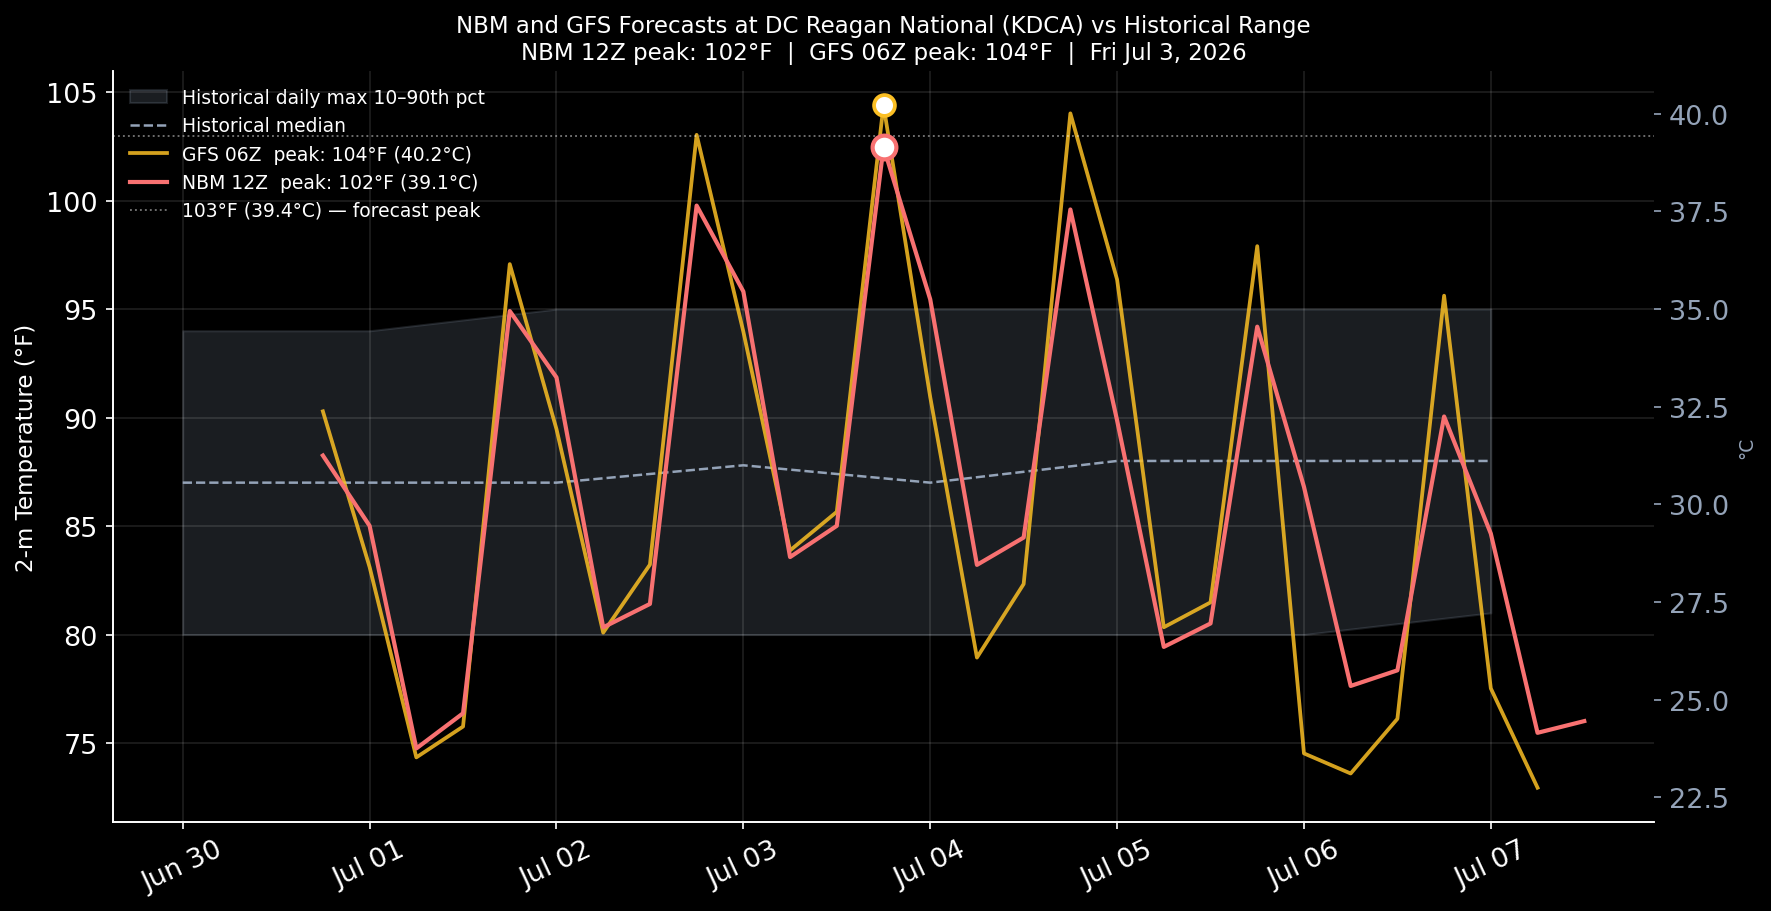

Saved figure_1_forecast.png


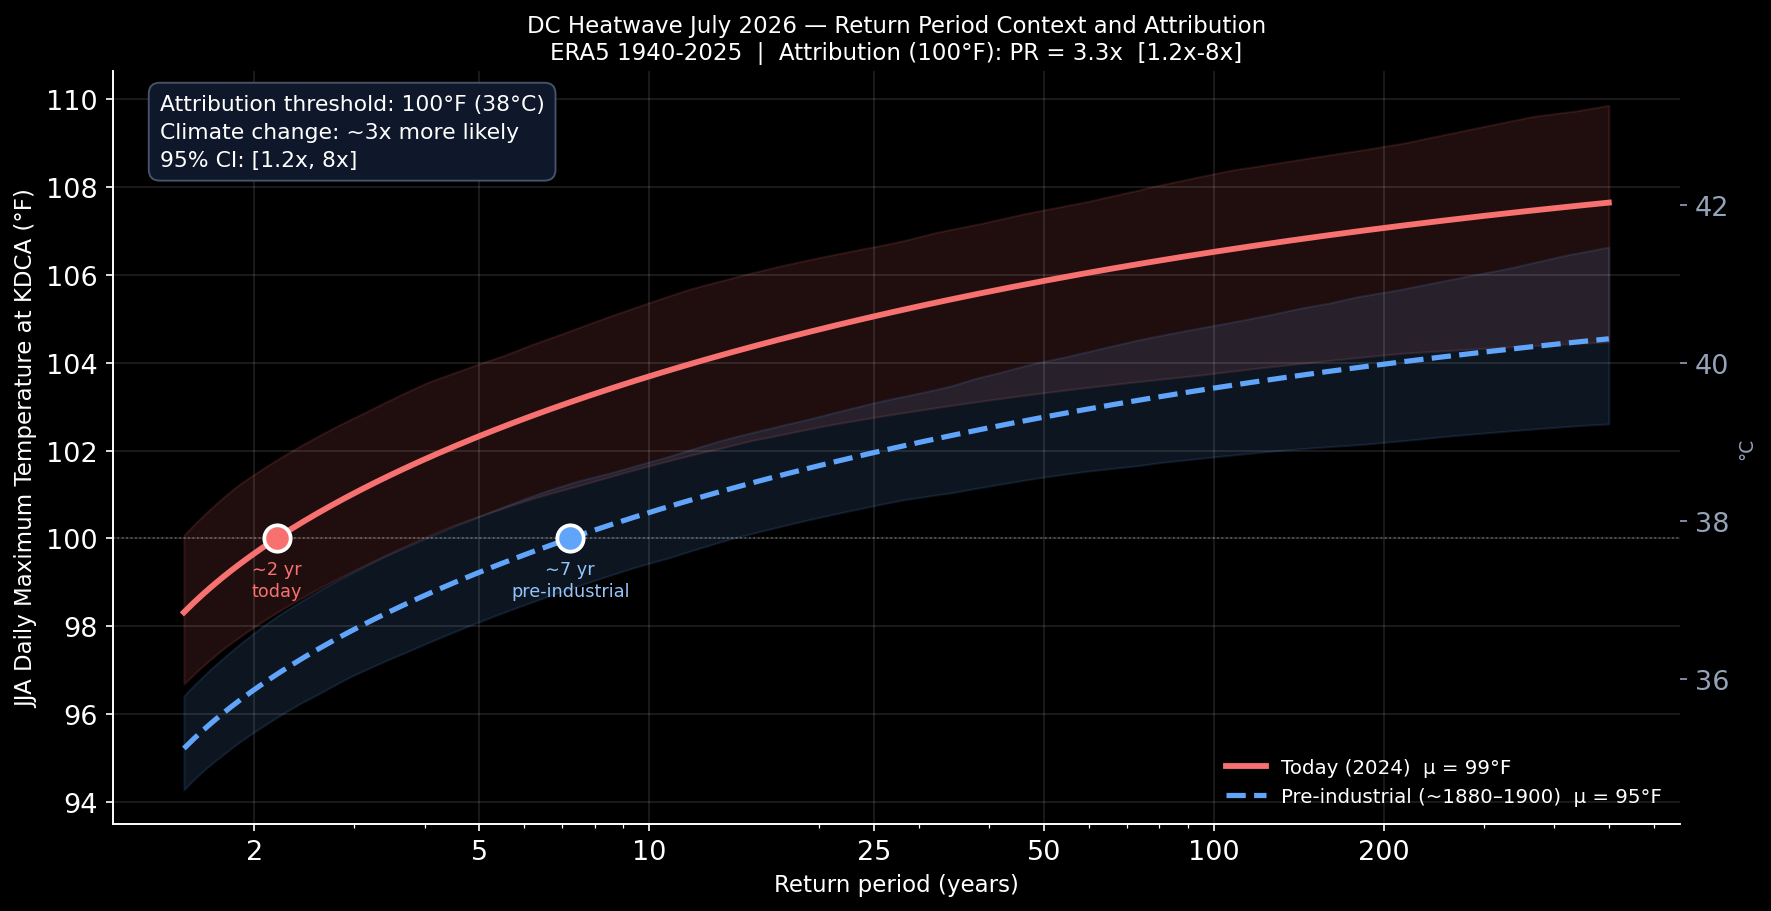

Saved fig_2_attribution.png


In [20]:
### Final Figures

LI_W, LI_H, LI_DPI = 12.0, 6.27, 200

def c_to_f(x): return x * 9/5 + 32

# Figure 1: NBM and GFS forecasts vs historical range
gfs_ts     = ds_gfs['t2m'] - 273.15          # K -> °C
gfs_peak_t = pd.Timestamp(gfs_ts.idxmax('time').values)
peak_103f_c = (103 - 32) * 5/9               # 39.444°C

fig, ax = plt.subplots(figsize=(LI_W, LI_H))

ax.fill_between(env['date'], c_to_f(env['p10']), c_to_f(env['p90']),
                color='#94a3b8', alpha=0.18, label='Historical daily max 10–90th pct')
ax.plot(env['date'], c_to_f(env['p50']),
        color='#94a3b8', lw=1.2, ls='--', label='Historical median')

# GFS 06Z (behind NBM)
ax.plot(pd.to_datetime(gfs_ts.time.values), c_to_f(gfs_ts.values),
        color='#fbbf24', lw=1.8, alpha=0.85, label=f'GFS 06Z  peak: {c_to_f(gfs_peak_c):.0f}°F ({gfs_peak_c:.1f}°C)')
ax.scatter([gfs_peak_t], [c_to_f(gfs_peak_c)],
           color='white', s=100, zorder=5, edgecolors='#fbbf24', lw=1.8)

# NBM 12Z (on top)
peak_time = pd.Timestamp(nbm_peak_time)
peak_f    = c_to_f(nbm_peak_c)
ax.plot(pd.to_datetime(kdca_ts.time.values), c_to_f(kdca_ts.values),
        color='#f87171', lw=2.0, label=f'NBM 12Z  peak: {peak_f:.0f}°F ({nbm_peak_c:.1f}°C)')
ax.scatter([peak_time], [peak_f],
           color='white', s=130, zorder=6, edgecolors='#f87171', lw=2.0)

# 103°F reference line
ax.axhline(c_to_f(peak_103f_c), color='white', lw=0.9, ls=':', alpha=0.45,
           label='103°F (39.4°C) — forecast peak')

ax.set_ylabel('2-m Temperature (°F)', fontsize=11)
ax.set_title(
    'NBM and GFS Forecasts at DC Reagan National (KDCA) vs Historical Range\n'
    f'NBM 12Z peak: {peak_f:.0f}°F  |  GFS 06Z peak: {c_to_f(gfs_peak_c):.0f}°F  |  Fri Jul 3, 2026',
    fontsize=11)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.12)
ax_c = ax.twinx()
ax_c.set_ylim((ax.get_ylim()[0]-32)*5/9, (ax.get_ylim()[1]-32)*5/9)
ax_c.set_ylabel('°C', color='#94a3b8', fontsize=9)
ax_c.tick_params(colors='#94a3b8')
fig.tight_layout()
plt.savefig(FIG_DIR / 'figure_1_forecast.png', dpi=LI_DPI, bbox_inches='tight')
plt.show()
print('Saved figure_1_forecast.png')

# Figure 2: ERA5 NS-GEV return period — today vs pre-industrial
fig, ax = plt.subplots(figsize=(LI_W, LI_H))

# CI bands
ax.fill_between(T_plot, c_to_f(ci_lo_f), c_to_f(ci_hi_f), color='#f87171', alpha=0.13)
ax.fill_between(T_plot, c_to_f(ci_lo_p), c_to_f(ci_hi_p), color='#60a5fa', alpha=0.13)

# Two GEV curves only — no green
ax.plot(T_plot, c_to_f(rl_factual_e), color='#f87171', lw=2.8,
        label=f'Today (2024)  μ = {c_to_f(mu_factual_e):.0f}°F')
ax.plot(T_plot, c_to_f(rl_pi_e),      color='#60a5fa', lw=2.5, ls='--',
        label=f'Pre-industrial (~1880–1900)  μ = {c_to_f(mu_pi_e):.0f}°F')

# Attribution threshold (100°F) — factual vs pre-industrial dots
ax.axhline(c_to_f(attr_threshold_c), color='white', lw=0.8, ls=':', alpha=0.3)
ax.scatter([rp_factual_e], [c_to_f(attr_threshold_c)],
           color='#f87171', s=160, zorder=5, edgecolors='white', lw=1.8)
ax.scatter([rp_pi_e], [c_to_f(attr_threshold_c)],
           color='#60a5fa', s=160, zorder=5, edgecolors='white', lw=1.8)
ax.text(rp_factual_e, c_to_f(attr_threshold_c) - 0.5,
        f'∼{rp_factual_e:.0f} yr\ntoday',
        color='#f87171', fontsize=8.5, ha='center', va='top', linespacing=1.3)
ax.text(rp_pi_e, c_to_f(attr_threshold_c) - 0.5,
        f'∼{rp_pi_e:.0f} yr\npre-industrial',
        color='#93c5fd', fontsize=8.5, ha='center', va='top', linespacing=1.3)

# Key result box — attribution at 100°F
ax.text(0.03, 0.97,
        f'Attribution threshold: 100°F (38°C)\n'
        f'Climate change: ~{PR_e:.0f}x more likely\n'
        f'95% CI: [{PR_ci_e[0]:.1f}x, {PR_ci_e[1]:.0f}x]',
        transform=ax.transAxes, fontsize=10.5,
        color='white', va='top', ha='left', linespacing=1.5,
        bbox=dict(boxstyle='round,pad=0.5', fc='#0f172a', ec='#475569', lw=0.9))

ax.set_xscale('log')
ax.set_xlabel('Return period (years)', fontsize=11)
ax.set_ylabel('JJA Daily Maximum Temperature at KDCA (°F)', fontsize=11)
ax.set_title(
    f'DC Heatwave July 2026 — Return Period Context and Attribution\n'
    f'ERA5 1940-2025  |  Attribution (100°F): PR = {PR_e:.1f}x  [{PR_ci_e[0]:.1f}x-{PR_ci_e[1]:.0f}x]',
    fontsize=11)
ax.set_xticks([2, 5, 10, 25, 50, 100, 200])
ax.set_xticklabels(['2', '5', '10', '25', '50', '100', '200'])
ax.legend(fontsize=9.5, loc='lower right')
ax.grid(alpha=0.12)
ax_c2 = ax.twinx()
ax_c2.set_ylim((ax.get_ylim()[0]-32)*5/9, (ax.get_ylim()[1]-32)*5/9)
ax_c2.set_ylabel('°C', color='#94a3b8', fontsize=9)
ax_c2.tick_params(colors='#94a3b8')
fig.tight_layout()
plt.savefig(FIG_DIR / 'fig_2_attribution.png', dpi=LI_DPI, bbox_inches='tight')
plt.show()
print('Saved fig_2_attribution.png')
